# **Post-Earnings Announcement Drift Analysis**

### **Introduction**

Post-earnings announcement drift (PEAD) is a financial anomaly in which a stock’s price continues to move in the direction of an earnings surprise for an extended period following the announcement. Positive earnings surprises are typically followed by upward abnormal returns, while negative surprises are followed by downward abnormal returns. This drift is commonly measured using cumulative abnormal returns (CAR) over an event window, typically up to 20 trading days or more after the earnings announcement.

A PEAD trading strategy is built upon the historical relationship between earnings surprises and subsequent abnormal return drift. By analysing past earnings events, investors can estimate the magnitude and duration of post-announcement drift. In real time, the strategy involves identifying the size and direction of the earnings surprise, observing the initial market reaction, and determining whether the price movement reflects underreaction or overreaction.

Rather than entering immediately during the announcement shock, investors may allow the initial volatility to stabilise before assessing whether a sustained drift is emerging. Positions are then taken in the direction of the earnings surprise and held for a duration consistent with historically observed drift persistence.

The prevailing explanation for PEAD is investor underreaction to new information, where market participants incorporate earnings news gradually rather than instantaneously. This delayed adjustment creates predictable momentum in abnormal returns following the announcement.

### ***Methodology***

The analysis begins by examining how Apple, Google, and NVIDIA respond to earnings announcements. For each announcement, we define an event window of 20 trading days following the earnings release. This window is chosen to capture both the immediate market reaction and any subsequent post-earnings drift.

To measure the market response, we calculate abnormal returns - the portion of a stock’s return that exceeds what would normally be expected given overall market movements. The calculation behind abnormal returns wills be explained at a later section. These abnormal returns are then accumulated over the event window to compute cumulative abnormal returns (CAR). CAR allows us to assess whether returns continue to move in the direction of the earnings surprise beyond the initial announcement.

We then extend the analysis by breaking down the price response into two components: the initial reaction and the subsequent drift. Specifically, we examine whether stocks tend to overreact (sharp move followed by reversal) or underreact (gradual adjustment over time). By analysing the average CAR path across events, we identify recurring behavioural patterns unique to each stock.

To refine this further, we incorporate reaction speed. This measures how quickly the market incorporates earnings information - for example, whether most of the abnormal return occurs in the first few days or gradually over a longer period. Slower initial reactions may indicate delayed information processing and therefore a longer-lasting drift.

Finally, we investigate the drivers of both the initial reaction and the drift. We examine whether factors such as earnings surprise magnitude, macroeconomic conditions, and prior price momentum influence the strength or duration of abnormal returns. This contextual layer helps determine under which market conditions a PEAD-based strategy is most viable.

## **Importing the Data**

In [1]:
import pandas as pd
import numpy as np

# Load data
earnings_import = pd.read_csv("earnings_regression_panel.csv")
prices_import = pd.read_csv("event_study_price_data.csv")

# Inspect
earnings_import.head()

,Ticker,Earnings Date,Surprise,CAR,Regime,VIX,Δ10Y
0,GOOGL,2005-04-21,0.0095,0.000635,0,14.41,0.035971
1,NVDA,2005-05-12,0.0040,0.026393,0,16.12,0.027027
2,AAPL,2005-07-13,0.0000,0.001773,0,10.84,-0.047945
3,GOOGL,2005-07-21,0.0035,0.006394,0,10.97,-0.009259
4,NVDA,2005-08-11,0.0000,0.002138,0,12.42,0.033493


In [2]:
# now inspect the price data
prices_import.head()

,ticker,date,open,high,low,close,volume,earnings_date,td_num,event_day,daily_return,daily_return_pct
0,AAPL,2005-01-03,1.16,1.16,1.12,1.13,12382431,NaN,0,NaN,NaN,NaN
1,AAPL,2005-01-04,1.14,1.17,1.12,1.14,19608238,NaN,1,NaN,0.008850,0.884956
2,AAPL,2005-01-05,1.15,1.17,1.14,1.15,12157876,NaN,2,NaN,0.008772,0.877193
3,AAPL,2005-01-06,1.16,1.16,1.13,1.15,12604964,NaN,3,NaN,0.000000,0.000000
4,AAPL,2005-01-07,1.16,1.24,1.16,1.24,39923768,NaN,4,NaN,0.078261,7.826087


This data has been taken from someone else in the group. We will not be needing all the data, including CAR, which will compute ourselves and thus some columns will be deleted.

In [3]:
#Copy the original dataframes to avoid modifying them directly
earnings_v1 = earnings_import.copy()
prices_v1 = prices_import.copy()

# drop CAR and 10Y columns
earnings_v1 = earnings_import.drop(columns=["CAR", "Δ10Y"])

# Earnings table
earnings_v2 = earnings_v1.rename(columns={
    "Ticker": "ticker",
    "Earnings Date": "event_date",
    "Surprise": "surprise",
    "Regime": "regime"
})

# this ensures that the event_date and prices columns is in datetime format and normalized to remove any time component
earnings_v2["event_date"] = pd.to_datetime(earnings_v2["event_date"]).dt.normalize() 
prices_v1["date"] = pd.to_datetime(prices_v1["date"]).dt.normalize()

prices_v1 = prices_v1.sort_values(["ticker", "date"])

In [4]:
# copy earnings_v2 to a final earnings df
earnings = earnings_v2.copy()

#save earnings
earnings.to_csv("earnings_data_import.csv", index=False)
# show the first few rows of the earnings data after renaming
earnings.head()

,ticker,event_date,surprise,regime,VIX
0,GOOGL,2005-04-21,0.0095,0,14.41
1,NVDA,2005-05-12,0.0040,0,16.12
2,AAPL,2005-07-13,0.0000,0,10.84
3,GOOGL,2005-07-21,0.0035,0,10.97
4,NVDA,2005-08-11,0.0000,0,12.42


In [5]:
# drop the daily return columns if they exist in the price data (we will recalculate them later)
prices_v1 = prices_v1.drop(columns=["daily_return", "daily_return_pct"], errors="ignore")

# save the cleaned and merged price data for later use
prices_v1.to_csv("prices_import.csv", index=False)

prices_v1.head()

,ticker,date,open,high,low,close,volume,earnings_date,td_num,event_day
0,AAPL,2005-01-03,1.16,1.16,1.12,1.13,12382431,NaN,0,NaN
1,AAPL,2005-01-04,1.14,1.17,1.12,1.14,19608238,NaN,1,NaN
2,AAPL,2005-01-05,1.15,1.17,1.14,1.15,12157876,NaN,2,NaN
3,AAPL,2005-01-06,1.16,1.16,1.13,1.15,12604964,NaN,3,NaN
4,AAPL,2005-01-07,1.16,1.24,1.16,1.24,39923768,NaN,4,NaN


---

## **Cumulative Abnormal Returns calculation**

#### ***Methodology***

We calculate *Abnormal Returns* ($AR$) and *Cumulative Abnormal Returns* ($CAR$) using the **Market Model**, which estimates each stock’s normal (expected) return based on its systematic relationship with the market.


#### **Returns**

Daily stock returns are computed using logarithmic returns:

$$
r_{i,t} = \ln\left(\frac{P_{i,t}}{P_{i,t-1}}\right)
$$

Market returns are computed similarly:

$$
r_{m,t} = \ln\left(\frac{M_t}{M_{t-1}}\right)
$$

where:

- $r_{i,t}$ = actual return of stock $i$ on day $t$  
- $r_{m,t}$ = market return on day $t$  
- $P_{i,t}$ = stock price  
- $M_t$ = market index level (NASDAQ-100 ETF, QQQ)  


#### **The Market Model (Expected Returns)**

The Market Model assumes that a stock’s return is composed of a systematic component driven by market movements and an idiosyncratic component:

$$
E[r_{i,t}] = \alpha_i + \beta_i r_{m,t} + \varepsilon_{i,t}
$$

Where:

- $\alpha_i$ represents the stock-specific average return not explained by the market  
- $\beta_i$ measures the stock’s sensitivity to market movements (systematic risk)  
- $\varepsilon_{i,t}$ represents the idiosyncratic (unexpected) return component  

The key assumption of the model is:

$$
E[\varepsilon_{i,t} \mid r_{m,t}] = 0
$$

Taking expectations conditional on market returns gives the expected (normal) return:

$$
E[r_{i,t} \mid r_{m,t}] = \alpha_i + \beta_i r_{m,t}
$$

The parameters $\alpha_i$ and $\beta_i$ are estimated using ordinary least squares (OLS) regression over a pre-event estimation window (e.g., $[-250,-30]$ trading days prior to the earnings announcement). This ensures expected returns are based solely on historical information and avoids look-ahead bias.


#### **Abnormal Returns**

Abnormal returns are defined as the deviation of actual returns from expected returns:

$$
AR_{i,t} = r_{i,t} - E[r_{i,t} \mid r_{m,t}]
$$

Substituting the market model expected return:

$$
AR_{i,t} = r_{i,t} - (\alpha_i + \beta_i r_{m,t})
$$

Under the model assumptions, abnormal returns correspond to the regression residuals:

$$
AR_{i,t} = \varepsilon_{i,t}
$$

Thus, abnormal returns represent the portion of stock performance that cannot be explained by systematic market movements.


#### **Cumulative Abnormal Returns**

Cumulative abnormal returns over an event window $(\tau_1, \tau_2)$ are computed as:

$$
CAR_i(\tau_1, \tau_2) = \sum_{t=\tau_1}^{\tau_2} AR_{i,t}
$$

Because log returns are additive, cumulative abnormal returns can be obtained through simple summation across the event window.



#### **Market Proxy**

To compute market returns we will use the NASDAQ-100 ETF (QQQ) is used as the market proxy due to its strong exposure to large-cap technology stocks, aligning closely with the firms in our sample and more accurately representing our stock's expected market movement.

In this analysis, abnormal returns are calculated using log returns rather than simple percentage returns. While both measures capture daily price changes, log returns are more appropriate when calculating cumulative abnormal returns (CAR) over multiple days.

A simple return is calculated as:
$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}​​
$$
This works well for measuring a single day’s return. However, when combining returns across multiple days, simple returns cannot simply be added together. Instead, they must be compounded:
$$
(1 + R_1)(1 + R_2)(1 + R_3) - 1
$$
This compounding makes cumulative calculations more complex and less convenient when analysing event windows.

Log returns, by contrast, are calculated as:
$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$
The key advantage of log returns is that they are additive over time. This means that cumulative log returns over multiple days can be obtained by simply summing daily log returns:
$$
\sum r_t​
$$
Because CAR involves accumulating abnormal returns across an event window (for example, 20 trading days), using log returns allows for straightforward summation while preserving the correct compounding effect.

Simple returns can certainly be used in event studies, but they must be compounded properly when calculating cumulative returns. Log returns provide a mathematically cleaner and more consistent approach when measuring multi-day drift, which is why they are preferred in this analysis.

This is well explained in this article: https://medium.com/@manojkotary/simple-returns-vs-log-returns-a-comprehensive-comparative-analysis-for-financial-analysis-702403693bad.

To summaries, it logarithmic returns produce much more accurate representations of return fluctuations and overall direction.


### **Computing Abnormal Returns**

#### **Importing NASDAQ 100 (QQQ) as market proxy and computing Market Returns**

In [6]:
import pandas as pd
import numpy as np
import yfinance as yf

# Pull QQQ separately (daily data)
start_date = "2005-01-01"   # should cover your price dataset span
end_date = "2025-12-31"

qqq = yf.download("QQQ", start=start_date, end=end_date, auto_adjust=True, progress=False)
qqq = qqq.reset_index().rename(columns={"Date":"date", "Close":"close", "Adj Close":"adj_close", "Volume":"volume", "Open":"open", "High":"high", "Low":"low"})
qqq["date"] = pd.to_datetime(qqq["date"]).dt.normalize()

# Flatten MultiIndex columns if present
if isinstance(qqq.columns, pd.MultiIndex):
    qqq.columns = qqq.columns.get_level_values(0)

qqq.head()


Price,date,close,high,low,open,volume
0,2005-01-03,33.695377,34.369286,33.584480,34.198676,100970900
1,2005-01-04,33.081196,33.900124,32.884995,33.840408,136623200
2,2005-01-05,32.876461,33.234740,32.816748,32.995887,127925500
3,2005-01-06,32.714348,33.021445,32.705819,32.953203,102934600
4,2005-01-07,32.884991,33.157966,32.594954,32.893523,123104000


In [7]:
# Compute daily log returns for QQQ
# we are adding a market return column to the QQQ dataframe
qqq["market_return"] = np.log(qqq["close"] / qqq["close"].shift(1))

# lets see the number of rows and columns in the QQQ dataframe
print(qqq.shape)
qqq.head()


(5282, 7)


Price,date,close,high,low,open,volume,market_return
0,2005-01-03,33.695377,34.369286,33.584480,34.198676,100970900,NaN
1,2005-01-04,33.081196,33.900124,32.884995,33.840408,136623200,-0.018396
2,2005-01-05,32.876461,33.234740,32.816748,32.995887,127925500,-0.006208
3,2005-01-06,32.714348,33.021445,32.705819,32.953203,102934600,-0.004943
4,2005-01-07,32.884991,33.157966,32.594954,32.893523,123104000,0.005203


#### **Computing Stock Returns**

In [8]:
# copy the cleaned price data to a new dataframe for further processing
prices = prices_v1.copy()

# Compute daily log returns
# uses groupby and transform to calculate log returns for each ticker separately
prices["stock_return"] = prices.groupby("ticker")["close"].transform(
    lambda x: np.log(x / x.shift(1)) # this calculates the log return for each stock by taking the log of the current close price divided by the previous day's close price
)


prices.head()

,ticker,date,open,high,low,close,volume,earnings_date,td_num,event_day,stock_return
0,AAPL,2005-01-03,1.16,1.16,1.12,1.13,12382431,NaN,0,NaN,NaN
1,AAPL,2005-01-04,1.14,1.17,1.12,1.14,19608238,NaN,1,NaN,0.008811
2,AAPL,2005-01-05,1.15,1.17,1.14,1.15,12157876,NaN,2,NaN,0.008734
3,AAPL,2005-01-06,1.16,1.16,1.13,1.15,12604964,NaN,3,NaN,0.000000
4,AAPL,2005-01-07,1.16,1.24,1.16,1.24,39923768,NaN,4,NaN,0.075349


#### **Merge QQQ onto the Stock Data**

In [9]:
# Make sure qqq has only date + market_return to merge cleanly
qqq_mkt = qqq[["date", "market_return"]].dropna().copy()

# Merge market returns into stock returns
prices = prices.merge(qqq_mkt, on="date", how="inner")

# Drop rows with missing returns (e.g., first day of each stock, or any missing market return)
prices = prices.dropna(subset=["stock_return", "market_return"]).copy()

# Build per-ticker indexed frames for fast event slicing
prices_by_ticker = {}
for t, df_t in prices.groupby("ticker"):
    df_t = df_t.sort_values("date").set_index("date")
    prices_by_ticker[t] = df_t

# Display the merged price data with returns
print("Merged prices shape:", prices.shape)
print("Tickers:", list(prices_by_ticker.keys()))
display(prices[["date","ticker","close","stock_return","market_return"]].head(10))


Merged prices shape: (15843, 12)
Tickers: ['AAPL', 'GOOGL', 'NVDA']


,date,ticker,close,stock_return,market_return
0,2005-01-04,AAPL,1.14,0.008811,-0.018396
1,2005-01-05,AAPL,1.15,0.008734,-0.006208
2,2005-01-06,AAPL,1.15,0.000000,-0.004943
3,2005-01-07,AAPL,1.24,0.075349,0.005203
4,2005-01-10,AAPL,1.23,-0.008097,-0.000519
5,2005-01-11,AAPL,1.15,-0.067252,-0.007032
6,2005-01-12,AAPL,1.17,0.017242,0.008329
7,2005-01-13,AAPL,1.25,0.066140,-0.013308
8,2005-01-14,AAPL,1.25,0.000000,0.009412
9,2005-01-18,AAPL,1.26,0.007968,0.007518


#### **Computing Abnormal Returns**

In [10]:
# Event-study AR using Market Model
# Estimation window: [-250, -30] trading days
# Event window:      [-5, +20] trading days
# For earnings events in 2022–2025 only

# import relevant libraries
import statsmodels.api as sm


# this function will be used to align the raw event date to the next available trading day if the raw event date is not a trading day. 
# It uses the searchsorted method to find the position where the event date would fit in the sorted stock_dates index, 
# and then returns the next trading day if the event date is not found in the stock_dates.
def align_to_next_trading_day(stock_dates: pd.Index, event_date: pd.Timestamp):
    """If event_date is not a trading day, push forward to next available trading day."""
    if event_date in stock_dates:
        return event_date
    pos = stock_dates.searchsorted(event_date)
    if pos >= len(stock_dates):
        return None
    return stock_dates[pos]

# This function fits the market model (CAPM) to the estimation window data for a given stock and event.
def fit_market_model(est_df: pd.DataFrame):
    """
    Fit r_i,t = alpha + beta * r_m,t + eps on the estimation window.
    Returns alpha, beta.
    """
    y = est_df["stock_return"].values
    X = sm.add_constant(est_df["market_return"].values)  # [1, r_m]
    model = sm.OLS(y, X).fit()
    alpha = model.params[0]
    beta = model.params[1]
    return alpha, beta

# Filter earnings events to 2022–2025 (inclusive)
earnings_22_25 = earnings[
    (earnings["event_date"] >= "2022-01-01") &
    (earnings["event_date"] <= "2025-12-31")
].copy()

# This loop iterates over each earnings event, 
# aligns the event date to the next trading day, 
# checks for sufficient data in the estimation and event windows, 
# fits the market model to the estimation window, 
# calculates expected returns and abnormal returns for the event window, 
# and collects all results into a single DataFrame.

L, R = 5, 60 # event window: [-5, +20]
EST_L, EST_R = 250, 30  # estimation window: [-250, -30]

rows = []

for _, ev in earnings_22_25.iterrows(): # loop through each earnings event in the filtered earnings dataframe
    tkr = ev["ticker"] # get the ticker for this event
    raw_event_date = ev["event_date"] # this is the raw event date from the earnings data, which we align to a trading day in the price data

    if tkr not in prices_by_ticker: # if we don't have price data for this ticker, skip it
        continue

    df_t = prices_by_ticker[tkr] # get the price data for this ticker
    idx = df_t.index # get the date index for this ticker's price data

    # Align event date to trading day
    t0_date = align_to_next_trading_day(idx, raw_event_date) # align the raw event date to the next trading day if it's not already a trading day
    if t0_date is None:
        continue

    t0 = idx.get_loc(t0_date) # get the integer location of the event date in the price data index

    # Need enough history for estimation + enough data for event window
    est_start = t0 - EST_L
    est_end   = t0 - EST_R
    evt_start = t0 - L
    evt_end   = t0 + R

# Check if we have enough data for estimation and event windows, for precaution
    if est_start < 0 or est_end < 0 or evt_start < 0 or evt_end >= len(idx): # if any of the start or end indices for estimation or event windows are out of bounds, skip this event
        continue
    if est_end - est_start + 1 < (EST_L - EST_R + 1): # if the number of observations in the estimation window is less than expected, skip this event
        continue

    # Estimation window slice (trading-day based)
    est_df = df_t.iloc[est_start:est_end+1][["stock_return", "market_return"]].dropna() # get the estimation window data for this event, and drop any rows with missing returns
    if len(est_df) < 100: # safety floor: if we have less than 100 observations in the estimation window after dropping NA, skip this event
        continue

    # Fit alpha, beta for THIS EVENT
    alpha, beta = fit_market_model(est_df)

    # Event window slice (trading-day based)
    evt_df = df_t.iloc[evt_start:evt_end+1][["stock_return", "market_return"]].copy() # get the event window data for this event

    # Computing Expected Return + AR
    evt_df["expected_return"] = alpha + beta * evt_df["market_return"] 
    evt_df["ar"] = evt_df["stock_return"] - evt_df["expected_return"]

    # Add relative day index: -5 ... +20
    evt_df["rel_day"] = np.arange(-L, R+1)

    # Attach event metadata
    evt_df["ticker"] = tkr
    evt_df["event_date_raw"] = raw_event_date
    evt_df["event_date_aligned"] = t0_date
    evt_df["alpha"] = alpha
    evt_df["beta"] = beta

    # carry through extra earnings columns if present
    for col in ["surprise", "regime", "VIX"]:
        if col in earnings_22_25.columns:
            evt_df[col] = ev.get(col, np.nan)

    evt_df = evt_df.reset_index().rename(columns={"index": "date"})
    rows.append(evt_df)

event_ar = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

# lets remove event_date_raw and regime

event_ar = event_ar.drop(columns=["event_date_raw", "regime"], errors="ignore")


print("event_ar shape:", event_ar.shape)
display(event_ar.head(15))

# Quick coverage checks
if not event_ar.empty:
    print("\nEvents per ticker:")
    display(event_ar.groupby("ticker")["event_date_aligned"].nunique().reset_index(name="n_events"))

    print("\nAR rows per ticker (should be n_events * 26):") # this checks how many AR observations we have for each ticker, which should be equal to the number of events for that ticker multiplied by 26 (the number of days in the event window from -5 to +20 inclusive)
    display(event_ar.groupby("ticker")["ar"].count().reset_index(name="n_ar_rows"))

    print("\nrel_day coverage check:") # this checks how many AR observations we have for each relative day in the event window, which should ideally be consistent across all relative days if we have good coverage of events and trading days
    display(event_ar.groupby("rel_day")["ar"].count().reset_index(name="count"))

event_ar shape: (2970, 12)


,date,stock_return,market_return,expected_return,ar,rel_day,ticker,event_date_aligned,alpha,beta,surprise,VIX
0,2022-01-20,-0.010401,-0.013074,-0.013834,0.003433,-5,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49
1,2022-01-21,-0.012847,-0.028120,-0.030008,0.017161,-4,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49
2,2022-01-24,-0.004876,0.004567,0.005129,-0.010005,-3,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49
3,2022-01-25,-0.011450,-0.023454,-0.024993,0.013542,-2,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49
4,2022-01-26,-0.000563,-0.001566,-0.001464,0.000900,-1,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49
5,2022-01-27,-0.002948,-0.010122,-0.010661,0.007713,0,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49
6,2022-01-28,0.067451,0.030887,0.033422,0.034029,1,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49
7,2022-01-31,0.025790,0.031478,0.034057,-0.008266,2,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49
8,2022-02-01,-0.000973,0.006781,0.007509,-0.008482,3,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49
9,2022-02-02,0.007020,0.008092,0.008919,-0.001899,4,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49



Events per ticker:


,ticker,n_events
0,AAPL,15
1,GOOGL,15
2,NVDA,15



AR rows per ticker (should be n_events * 26):


,ticker,n_ar_rows
0,AAPL,990
1,GOOGL,990
2,NVDA,990



rel_day coverage check:


,rel_day,count
0,-5,45
1,-4,45
2,-3,45
3,-2,45
4,-1,45
...,...,...
61,56,45
62,57,45
63,58,45
64,59,45


#### **Computing CAR Reaction Windows**

In [11]:
# =========================================
# Add CAR(0,t) to event_ar
# =========================================

# Sort properly
event_ar = event_ar.sort_values(
    ["ticker", "event_date_aligned", "rel_day"]
).copy()

# Keep only post-event days for accumulation
event_ar["car_0_t"] = np.nan

mask_post = event_ar["rel_day"] >= 0

event_ar.loc[mask_post, "car_0_t"] = (
    event_ar[mask_post]
    .groupby(["ticker", "event_date_aligned"])["ar"]
    .cumsum()
)

# save the updated event_ar dataframe with CAR(0,t) for later use
event_ar.to_csv("event_ar_with_car.csv", index=False)

event_ar.head(15)

,date,stock_return,market_return,expected_return,ar,rel_day,ticker,event_date_aligned,alpha,beta,surprise,VIX,car_0_t
0,2022-01-20,-0.010401,-0.013074,-0.013834,0.003433,-5,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49,NaN
1,2022-01-21,-0.012847,-0.028120,-0.030008,0.017161,-4,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49,NaN
2,2022-01-24,-0.004876,0.004567,0.005129,-0.010005,-3,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49,NaN
3,2022-01-25,-0.011450,-0.023454,-0.024993,0.013542,-2,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49,NaN
4,2022-01-26,-0.000563,-0.001566,-0.001464,0.000900,-1,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49,NaN
5,2022-01-27,-0.002948,-0.010122,-0.010661,0.007713,0,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49,0.007713
6,2022-01-28,0.067451,0.030887,0.033422,0.034029,1,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49,0.041742
7,2022-01-31,0.025790,0.031478,0.034057,-0.008266,2,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49,0.033476
8,2022-02-01,-0.000973,0.006781,0.007509,-0.008482,3,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49,0.024994
9,2022-02-02,0.007020,0.008092,0.008919,-0.001899,4,AAPL,2022-01-27,0.00022,1.074957,0.21,30.49,0.023095


#### **Visualisations of CAR per Ticker**

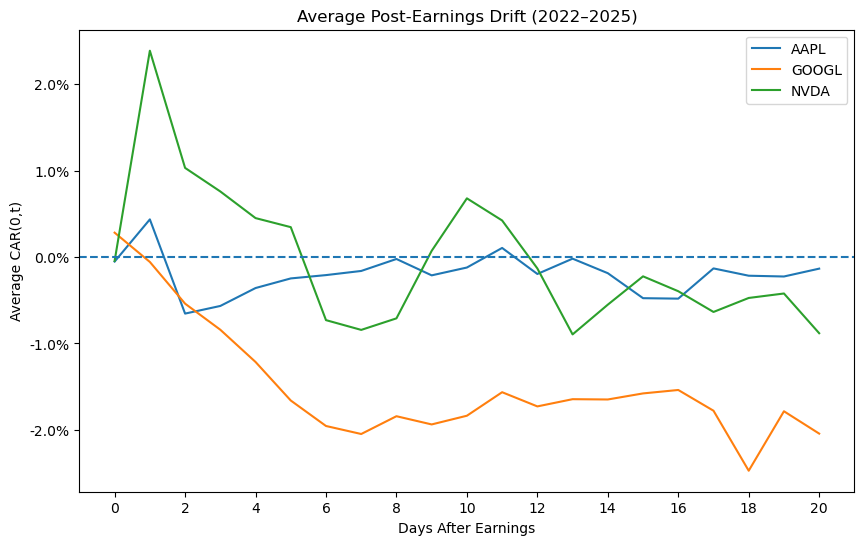

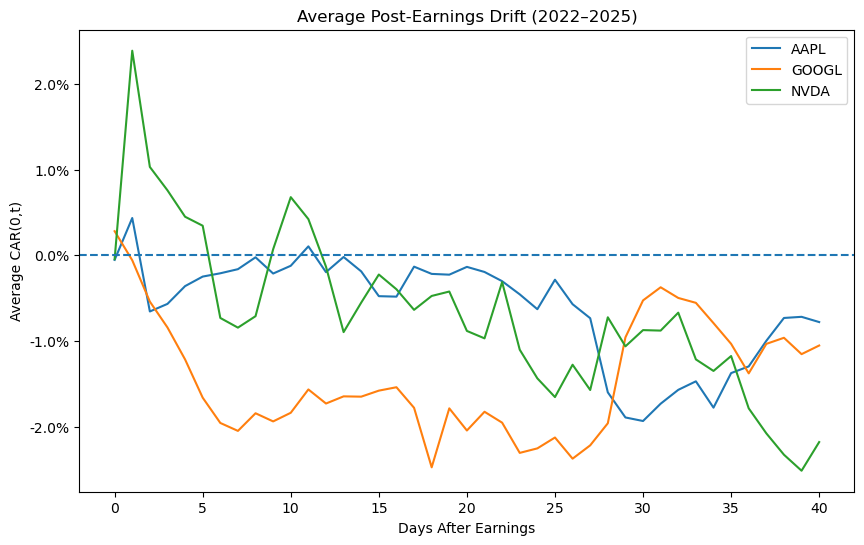

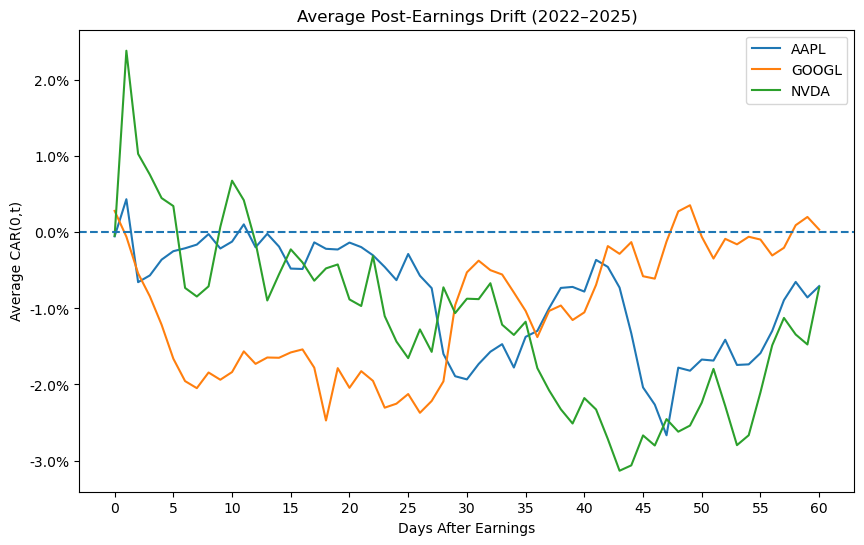

In [12]:
import matplotlib.pyplot as plt


# Now we visualise the average post-earnings drift by plotting the average CAR(0,t) across events for each ticker.
# First we do CAR(0,20)
drift = event_ar[event_ar["rel_day"].between(0,20)].copy()

# Average across events
avg_car = (
    drift.groupby(["ticker", "rel_day"])["car_0_t"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

for t in avg_car["ticker"].unique():
    df_t = avg_car[avg_car["ticker"] == t]
    plt.plot(df_t["rel_day"], df_t["car_0_t"], label=t)

plt.xticks(range(0, 21, 2))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
plt.axhline(0, linestyle="--")
plt.xlabel("Days After Earnings")
plt.ylabel("Average CAR(0,t)")
plt.title("Average Post-Earnings Drift (2022–2025)")
plt.legend()
plt.show()

# Next we do CAR(0,40)
drift = event_ar[event_ar["rel_day"].between(0,40)].copy()

# Average across events
avg_car = (
    drift.groupby(["ticker", "rel_day"])["car_0_t"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

for t in avg_car["ticker"].unique():
    df_t = avg_car[avg_car["ticker"] == t]
    plt.plot(df_t["rel_day"], df_t["car_0_t"], label=t)

plt.xticks(range(0, 41, 5))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
plt.axhline(0, linestyle="--")
plt.xlabel("Days After Earnings")
plt.ylabel("Average CAR(0,t)")
plt.title("Average Post-Earnings Drift (2022–2025)")
plt.legend()
plt.show()


# Next we do CAR(0,60)
drift = event_ar[event_ar["rel_day"].between(0,60)].copy()

# Average across events
avg_car = (
    drift.groupby(["ticker", "rel_day"])["car_0_t"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

for t in avg_car["ticker"].unique():
    df_t = avg_car[avg_car["ticker"] == t]
    plt.plot(df_t["rel_day"], df_t["car_0_t"], label=t)

plt.xticks(range(0, 61, 5))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
plt.axhline(0, linestyle="--")
plt.xlabel("Days After Earnings")
plt.ylabel("Average CAR(0,t)")
plt.title("Average Post-Earnings Drift (2022–2025)")
plt.legend()
plt.show()

----

In [13]:
def car_window(df_event, a, b):
    return df_event.loc[df_event["rel_day"].between(a, b), "ar"].sum()

rows = []

for (tkr, ed), df_e in event_ar.groupby(["ticker", "event_date_aligned"]):
    # Core windows
    CAR_01   = car_window(df_e, 0, 1)     # immediate reaction
    CAR_05   = car_window(df_e, 0, 5)     # reaction + early adjustment
    CAR_220  = car_window(df_e, 2, 20)    # drift window (classic)
    CAR_240  = car_window(df_e, 2, 40)    # extended drift
    CAR_260  = car_window(df_e, 2, 60)    # extended drift
    CAR_020  = car_window(df_e, 0, 20)
    CAR_040  = car_window(df_e, 0, 40)
    CAR_060  = car_window(df_e, 0, 60)

    # Speed metric (your earlier idea): fraction of total 0–5 move realized by day 1
    speed = np.nan
    if abs(CAR_05) > 1e-12:
        speed = abs(CAR_01) / abs(CAR_05)

    # Continuation vs reversal (reaction sign vs drift sign)
    # continuation: same sign; reversal: opposite sign
    continuation = np.nan
    if (CAR_01 != 0) and (CAR_220 != 0):
        continuation = (np.sign(CAR_01) == np.sign(CAR_220))

    rows.append({
        "ticker": tkr,
        "event_date": ed,
        "CAR_0_1": CAR_01,
        "CAR_0_5": CAR_05,
        "CAR_2_20": CAR_220,
        "CAR_2_40": CAR_240,
        "CAR_2_60": CAR_260,
        "CAR_0_20": CAR_020,
        "CAR_0_40": CAR_040,
        "CAR_0_60": CAR_060,
        "speed_01_over_05": speed,
        "continuation_01_vs_220": continuation
    })

event_metrics = pd.DataFrame(rows).sort_values(["ticker","event_date"]).reset_index(drop=True)

# save the event_metrics dataframe for later use
event_metrics.to_csv("event_metrics.csv", index=False)

event_metrics.head()

,ticker,event_date,CAR_0_1,CAR_0_5,CAR_2_20,CAR_2_40,CAR_2_60,CAR_0_20,CAR_0_40,CAR_0_60,speed_01_over_05,continuation_01_vs_220
0,AAPL,2022-01-27,0.041742,0.050505,-0.018291,-0.007273,0.011122,0.023451,0.034469,0.052864,0.826492,False
1,AAPL,2022-04-28,0.015712,0.007535,-0.065070,-0.076475,-0.031488,-0.049358,-0.060763,-0.015775,2.085165,False
2,AAPL,2022-07-28,0.007696,-0.002058,0.014811,0.019469,-0.017291,0.022506,0.027164,-0.009595,3.740286,True
3,AAPL,2022-10-27,0.028446,-0.018392,-0.091288,-0.166260,-0.185822,-0.062842,-0.137814,-0.157377,1.546613,False
4,AAPL,2023-02-02,0.043029,0.033666,-0.003018,0.013142,0.035474,0.040011,0.056171,0.078503,1.278108,False


---

## **Continuation vs Reversal & Reaction Speed Analysis**

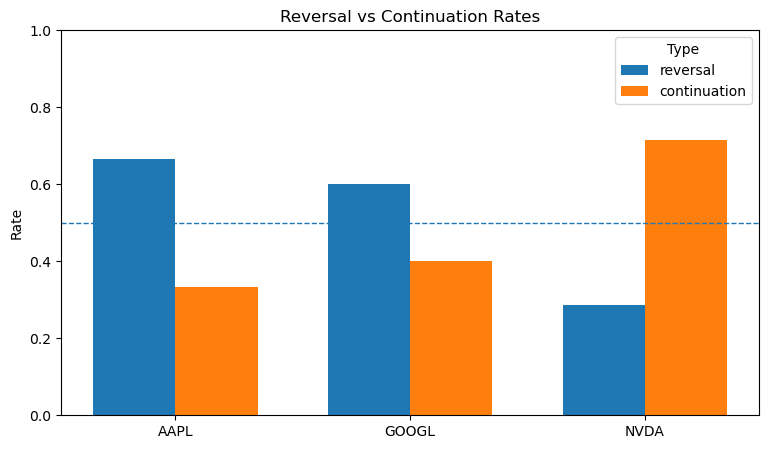

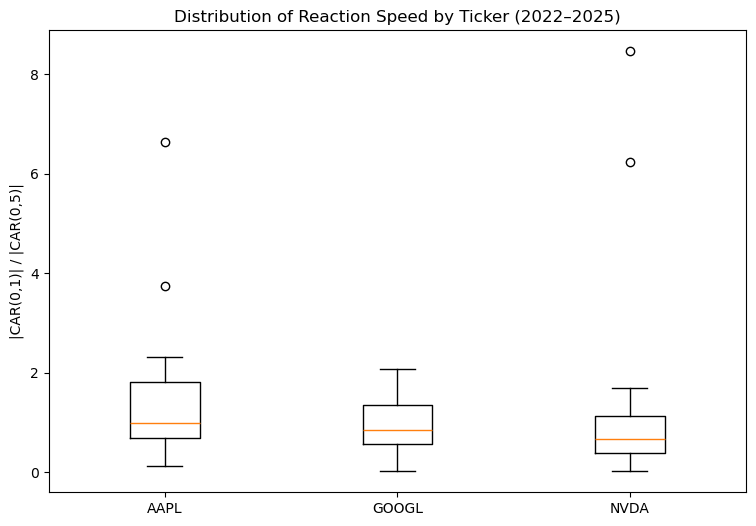


Speed summary stats by ticker (2022–2025):


,count,mean,median,std,min,max,p10,p25,p50,p75,p90
ticker,,,,,,,,,,,
AAPL,15,1.609953,0.996057,1.663112,0.113996,6.627809,0.449566,0.687187,0.996057,1.815889,3.170920
GOOGL,15,0.982105,0.835780,0.607960,0.021000,2.065506,0.411175,0.567167,0.835780,1.344898,1.901031
NVDA,14,1.619514,0.669381,2.510259,0.015726,8.459634,0.075489,0.389172,0.669381,1.120119,4.877568


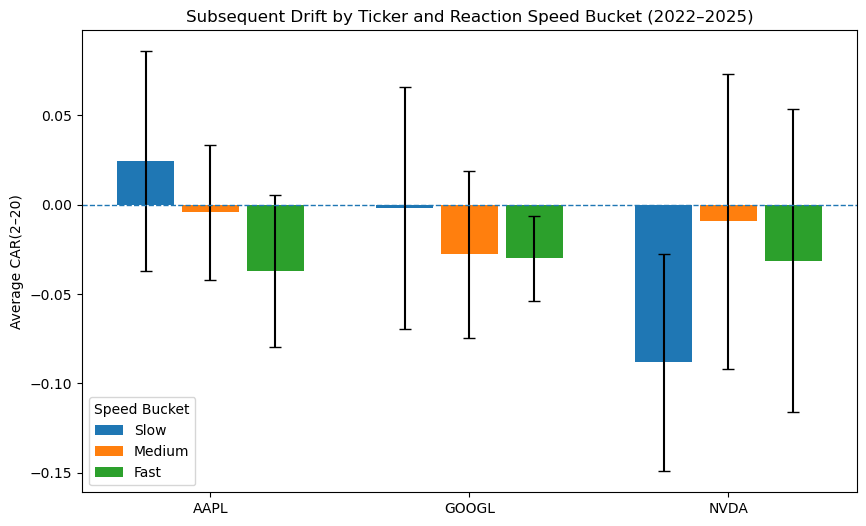

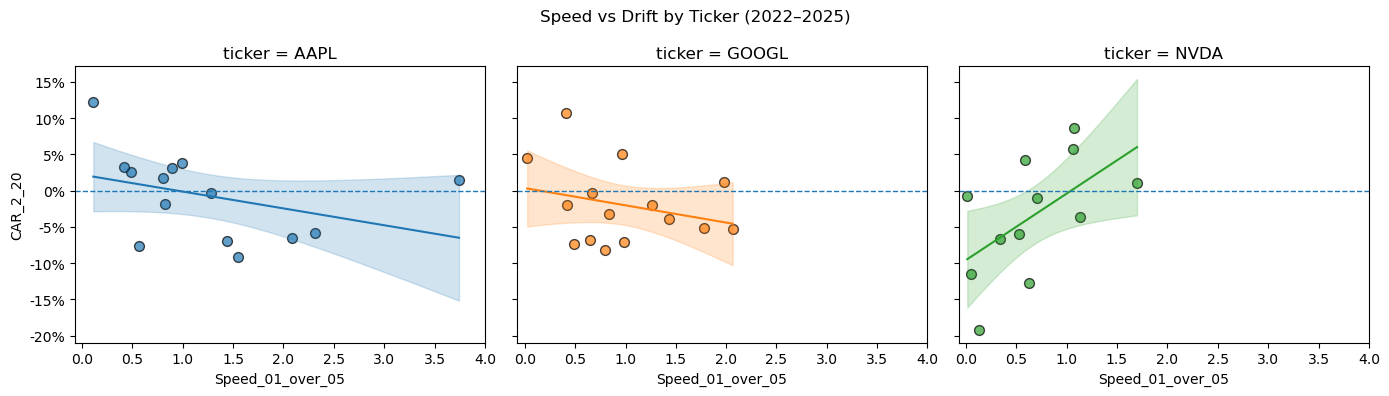

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# =========================
# Setup / clean
# =========================
df = event_metrics.copy()

# Keep only relevant columns & drop missing where needed
df = df.dropna(subset=["ticker"]).copy()

# this filters out any events where the speed metric is missing or greater than 10, which helps to focus the analysis on events with reasonable reaction speeds and avoids extreme outliers that could skew the results. You can adjust the threshold as needed based on the distribution of the speed metric in your data.
df = df[(df["speed_01_over_05"].notna()) & (df["speed_01_over_05"] <= 10)].copy()

tickers = sorted(df["ticker"].unique())

# =========================
# 1) Continuation vs Reversal rates (grouped bar, side-by-side tickers)
# =========================
cont_df = df.dropna(subset=["continuation_01_vs_220"]).copy()
rates = (cont_df.groupby("ticker")["continuation_01_vs_220"]
         .mean()
         .reindex(tickers))

cont_rates = rates.values
rev_rates = 1 - cont_rates

x = np.arange(len(tickers))
w = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - w/2, rev_rates, width=w, label="reversal")
plt.bar(x + w/2, cont_rates, width=w, label="continuation")
plt.xticks(x, tickers)
plt.ylim(0, 1)
plt.ylabel("Rate")
plt.title("Reversal vs Continuation Rates")
plt.legend(title="Type")
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.show()


# =========================
# 2) Speed distribution by ticker (boxplot side-by-side)
# =========================
speed_df = df.dropna(subset=["speed_01_over_05"]).copy()

# we create a list of arrays, where each array contains the speed metric values for a specific ticker. 
# This structure is suitable for creating a boxplot that compares the distribution of the speed metric across different tickers side by side.
data = [speed_df.loc[speed_df["ticker"] == t, "speed_01_over_05"].values for t in tickers]

plt.figure(figsize=(9,6))
plt.boxplot(data, tick_labels=tickers, showfliers=True)
plt.ylabel("|CAR(0,1)| / |CAR(0,5)|")
plt.title("Distribution of Reaction Speed by Ticker (2022–2025)")
plt.show()


# =========================
# 2b) Speed summary stats (per ticker)
# =========================
speed_summary = (
    speed_df.groupby("ticker")["speed_01_over_05"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
)

# Add percentiles (useful since distribution is skewed / has outliers)
pcts = speed_df.groupby("ticker")["speed_01_over_05"].quantile([0.10, 0.25, 0.50, 0.75, 0.90]).unstack()
pcts.columns = ["p10","p25","p50","p75","p90"]

speed_summary = speed_summary.join(pcts)

print("\nSpeed summary stats by ticker (2022–2025):")
display(speed_summary)

# =========================
# 3) Speed buckets (Slow/Medium/Fast) based on within-ticker distribution
#    Then plot mean Drift CAR(2,20) with 95% CI error bars
# =========================

# =========================
# 3a) Build speed buckets + summary_speed for the bar chart
# =========================
bucketed = df.dropna(subset=["speed_01_over_05", "CAR_2_20"]).copy()

def assign_bucket_within_ticker(g):
    q1 = g["speed_01_over_05"].quantile(0.33)
    q2 = g["speed_01_over_05"].quantile(0.66)

    def lab(x):
        if x <= q1:
            return "Slow"
        elif x <= q2:
            return "Medium"
        else:
            return "Fast"

    g = g.copy()
    g["speed_bucket"] = g["speed_01_over_05"].apply(lab)
    g["speed_bucket"] = pd.Categorical(g["speed_bucket"], ["Slow","Medium","Fast"], ordered=True)
    return g

bucketed = df.dropna(subset=["speed_01_over_05", "CAR_2_20"]).copy()

bucketed["q1"] = bucketed.groupby("ticker")["speed_01_over_05"].transform(lambda s: s.quantile(0.33))
bucketed["q2"] = bucketed.groupby("ticker")["speed_01_over_05"].transform(lambda s: s.quantile(0.66))

bucketed["speed_bucket"] = np.where(
    bucketed["speed_01_over_05"] <= bucketed["q1"], "Slow",
    np.where(
        bucketed["speed_01_over_05"] <= bucketed["q2"], "Medium",
        "Fast"
    )
)

bucketed["speed_bucket"] = pd.Categorical(
    bucketed["speed_bucket"],
    ["Slow","Medium","Fast"],
    ordered=True
)

bucketed = bucketed.drop(columns=["q1","q2"])
summary_speed = (bucketed
    .groupby(["ticker","speed_bucket"], observed=False)["CAR_2_20"]
    .agg(["count","mean","std"])
    .reset_index()
)

summary_speed["se"] = summary_speed["std"] / np.sqrt(summary_speed["count"])
summary_speed["ci95"] = 1.96 * summary_speed["se"]

plt.figure(figsize=(10,6))

bucket_order = ["Slow","Medium","Fast"]
offsets = {"Slow": -0.25, "Medium": 0.0, "Fast": 0.25}
bar_w = 0.22

# Consistent color mapping
color_map = {
    "Slow": "#1f77b4",    # Blue
    "Medium": "#ff7f0e",  # Orange
    "Fast": "#2ca02c"     # Green
}

# this loop iterates over each ticker and each speed bucket, filters the summary dataframe to get the mean and confidence interval for the specific ticker and speed bucket, and then plots a bar with error bars representing the 95% confidence interval for the mean CAR(2,20) for that group. The bars are colored consistently based on the speed bucket, and a legend is added to indicate which color corresponds to which speed bucket.
for i, t in enumerate(tickers):
    for b in bucket_order:
        # this filters the summary dataframe to get the mean and confidence interval for the specific ticker and speed bucket, which are then used to plot the bar with error bars representing the 95% confidence interval for the mean CAR(2,20) for that group.
        s = summary_speed[(summary_speed["ticker"] == t) & (summary_speed["speed_bucket"] == b)]
        if s.empty:
            continue
        
        y = float(s["mean"].iloc[0])
        e = float(s["ci95"].iloc[0])
        
        plt.bar(
            i + offsets[b],
            y,
            width=bar_w,
            yerr=e,
            capsize=4,
            color=color_map[b],      # <-- fixed color per speed bucket
            label=b if i == 0 else ""
        )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(range(len(tickers)), tickers)
plt.ylabel("Average CAR(2–20)")
plt.title("Subsequent Drift by Ticker and Reaction Speed Bucket (2022–2025)")
plt.legend(title="Speed Bucket")
plt.show()

# =========================
# 4) Speed vs Drift scatter (CAR 2–20), ticker side-by-side with regression + CI
#    (Matplotlib-only OLS fit + approximate 95% CI for mean prediction)
# =========================
from math import sqrt

#similar to 1), lets filter out any speed above 4
bucketed = bucketed[bucketed["speed_01_over_05"] <= 4].copy()

# we want to add hue per ticker to be different for better visibility
# this creates a color mapping for each ticker, assigning a unique color (C0, C1, C2, etc.) to each ticker in the list of tickers. This mapping is used later in the plotting code to ensure that each ticker's points and regression line are colored consistently across the different subplots.

# =========================
# Ticker color mapping (consistent across plots)
# =========================
TICKERS = ["AAPL", "GOOGL", "NVDA"]  # or sorted(event_level["ticker"].unique())

TICKER_COLORS = {
    ticker: f"C{i}" for i, ticker in enumerate(TICKERS)
}


color_map_ticker = TICKER_COLORS

fig, axes = plt.subplots(1, len(tickers), figsize=(14,4), sharey=True)

for ax, t in zip(axes, tickers):
    d = bucketed[bucketed["ticker"] == t].dropna(subset=["speed_01_over_05","CAR_2_20"]).copy()
    x = d["speed_01_over_05"].values
    y = d["CAR_2_20"].values

    ax.scatter(x, y, color=color_map_ticker[t], alpha=0.7, edgecolor='k', s=50)

    # OLS: y = a + b x
    if len(d) >= 3 and np.std(x) > 0:
        X = np.column_stack([np.ones_like(x), x])
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        a, b = beta[0], beta[1]

        # grid for line
        xg = np.linspace(x.min(), x.max(), 100)
        yg = a + b * xg

        # residual variance
        yhat = a + b * x
        resid = y - yhat
        n = len(x)
        s2 = (resid @ resid) / (n - 2)

        xbar = x.mean()
        Sxx = np.sum((x - xbar)**2)

        # 95% CI for mean prediction: yg ± 1.96 * sqrt(s2 * (1/n + (xg-xbar)^2 / Sxx))
        if Sxx > 0:
            se_mean = np.sqrt(s2 * (1/n + (xg - xbar)**2 / Sxx))
            ci = 1.96 * se_mean
            ax.plot(xg, yg, color=color_map_ticker[t])
            ax.fill_between(xg, yg - ci, yg + ci, alpha=0.2, color=color_map_ticker[t])
        else:
            ax.plot(xg, yg, color=color_map_ticker[t])

# we set the x axis in intervals of 0.5 and maintain a 1 decimal format for the speed metric on the x-axis. 
# The y-axis is formatted as percentages for better readability, and a horizontal dashed line is added at y=0 to help visualize whether the CAR(2,20) values are generally positive or negative across the range of the speed metric.
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"ticker = {t}")
    ax.set_xlabel("Speed_01_over_05")
    ax.set_xticks(np.arange(0, 4.5, 0.5))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

axes[0].set_ylabel("CAR_2_20")
fig.suptitle("Speed vs Drift by Ticker (2022–2025)")
plt.tight_layout()
plt.show()

---

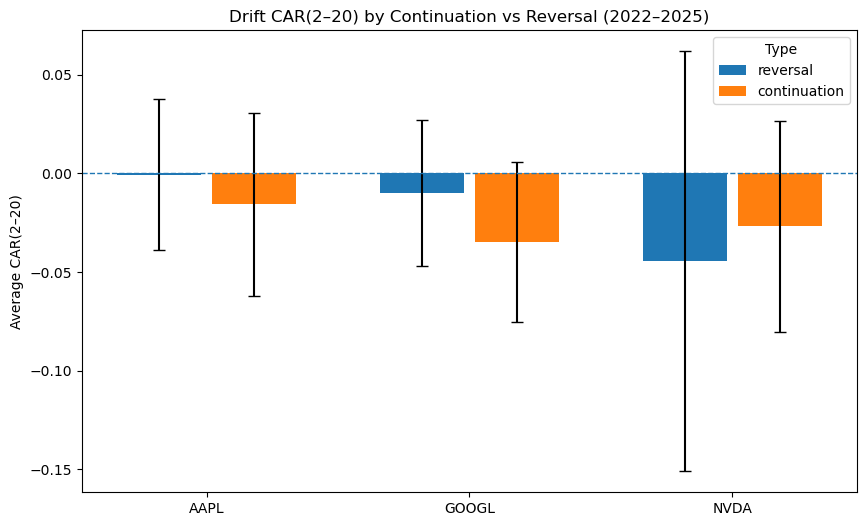

In [15]:
# we first filter the event_metrics dataframe to keep only rows where both the continuation indicator (continuation_01_vs_220) and the CAR(2,20) metric are not missing. This ensures that we have valid data for both the continuation/reversal classification and the subsequent drift measurement before we proceed with the analysis and visualization.
df = event_metrics.dropna(subset=["continuation_01_vs_220", "CAR_2_20"]).copy()

# Map to labels (continuation True/False -> strings)
df["cont_type"] = np.where(df["continuation_01_vs_220"], "continuation", "reversal")

tickers = sorted(df["ticker"].unique())
types = ["reversal", "continuation"]
offsets = {"reversal": -0.18, "continuation": 0.18}
bar_w = 0.32

# Summary_cont stats
summary_cont = (df.groupby(["ticker", "cont_type"], observed=False)["CAR_2_20"]
             .agg(["count", "mean", "std"])
             .reset_index())
summary_cont["se"] = summary_cont["std"] / np.sqrt(summary_cont["count"])
summary_cont["ci95"] = 1.96 * summary_cont["se"]

# Fixed colors for consistency
color_map = {"reversal": "#1f77b4", "continuation": "#ff7f0e"}

plt.figure(figsize=(10,6))

for i, t in enumerate(tickers):
    for typ in types:
        s = summary_cont[(summary_cont["ticker"] == t) & (summary_cont["cont_type"] == typ)]
        if s.empty:
            continue
        y = float(s["mean"].iloc[0])
        e = float(s["ci95"].iloc[0])

        plt.bar(i + offsets[typ], y, width=bar_w, yerr=e, capsize=4,
                color=color_map[typ], label=typ if i == 0 else "")

plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(range(len(tickers)), tickers)
plt.ylabel("Average CAR(2–20)")
plt.title("Drift CAR(2–20) by Continuation vs Reversal (2022–2025)")
plt.legend(title="Type")
plt.show()

---


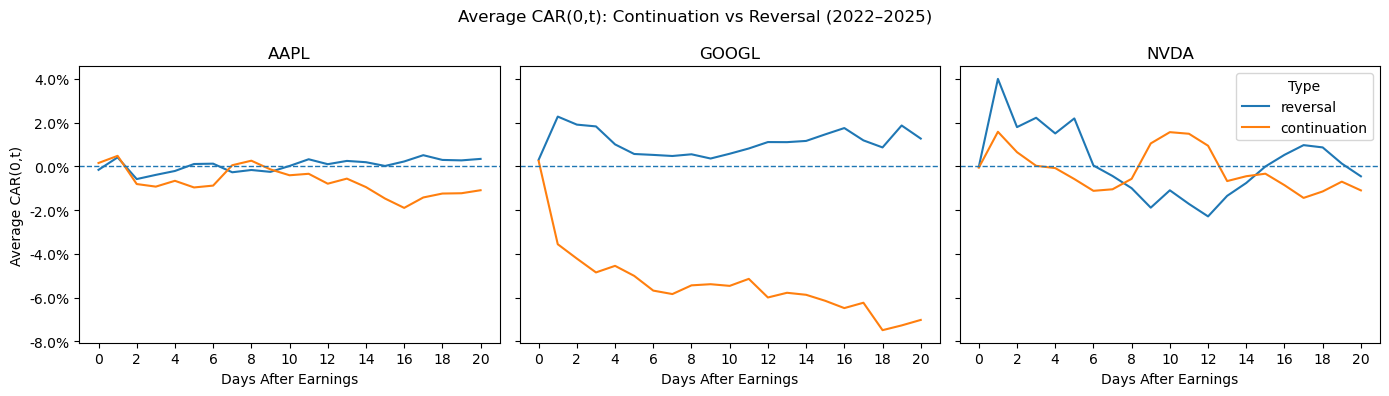

TypeError: Choicelist and default value do not have a common dtype: The DType <class 'numpy.dtypes._PyLongDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyLongDType'>)

In [16]:
# Keep only the timeline we want
panel_0_20 = event_ar[event_ar["rel_day"].between(0, 20)].copy()


from matplotlib.ticker import FuncFormatter

# =========================================================
# 1) Build a robust event_id to merge event_metrics -> event_ar
#    event_id = "TICKER|YYYY-MM-DD"
# =========================================================
panel_0_20["event_id"] = (
    panel_0_20["ticker"].astype(str) + "|" +
    pd.to_datetime(panel_0_20["event_date_aligned"]).dt.strftime("%Y-%m-%d")
)

em = event_metrics.copy()
em["event_id"] = (
    em["ticker"].astype(str) + "|" +
    pd.to_datetime(em["event_date"]).dt.strftime("%Y-%m-%d")
)

# =========================================================
# 2) Add continuation/reversal label to the daily panel
# =========================================================
em_cont = em[["event_id", "ticker", "continuation_01_vs_220"]].drop_duplicates().copy()
em_cont["cont_type"] = np.where(em_cont["continuation_01_vs_220"], "continuation", "reversal")

panel = panel_0_20.merge(em_cont[["event_id", "ticker", "cont_type"]],
                         on=["event_id", "ticker"], how="inner")

tickers = sorted(panel["ticker"].unique())

# Color mapping (consistent)
cont_colors = {"reversal": "#1f77b4", "continuation": "#ff7f0e"}

# =========================================================
# FIGURE A) Continuation vs Reversal CAR(0,t) curves (side-by-side)
# =========================================================
fig, axes = plt.subplots(1, len(tickers), figsize=(14,4), sharey=True)

for ax, tkr in zip(axes, tickers):
    d = panel[panel["ticker"] == tkr].copy()

    avg = (d.groupby(["cont_type", "rel_day"], observed=False)["car_0_t"]
             .mean()
             .reset_index())

    for typ in ["reversal", "continuation"]:
        dd = avg[avg["cont_type"] == typ]
        if dd.empty:
            continue
        ax.plot(dd["rel_day"], dd["car_0_t"], label=typ, color=cont_colors[typ])

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"{tkr}")
    ax.set_xlabel("Days After Earnings")

    ax.set_xticks(range(0, 21, 2))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

axes[0].set_ylabel("Average CAR(0,t)")
fig.suptitle("Average CAR(0,t): Continuation vs Reversal (2022–2025)")
axes[-1].legend(title="Type")
plt.xticks(range(0, 21, 2))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
plt.tight_layout()
plt.show()


# =========================================================
# 3) Build speed buckets (Slow/Medium/Fast) within ticker using event_metrics
# =========================================================
speed_src = em.dropna(subset=["speed_01_over_05"]).copy()

def assign_bucket_within_ticker(g):
    q1 = g["speed_01_over_05"].quantile(0.33)
    q2 = g["speed_01_over_05"].quantile(0.66)

    def lab(x):
        if x <= q1:
            return "Slow"
        elif x <= q2:
            return "Medium"
        else:
            return "Fast"

    g = g.copy()
    g["speed_bucket"] = g["speed_01_over_05"].apply(lab)
    g["speed_bucket"] = pd.Categorical(g["speed_bucket"], ["Slow","Medium","Fast"], ordered=True)
    return g

speed_src = em.dropna(subset=["speed_01_over_05"]).copy()

# Compute within-ticker 33% and 66% thresholds using transform
speed_src["q1"] = speed_src.groupby("ticker")["speed_01_over_05"].transform(lambda x: x.quantile(0.33))
speed_src["q2"] = speed_src.groupby("ticker")["speed_01_over_05"].transform(lambda x: x.quantile(0.66))

# Assign bucket without groupby.apply
conditions = [
    speed_src["speed_01_over_05"] <= speed_src["q1"],
    (speed_src["speed_01_over_05"] > speed_src["q1"]) & 
    (speed_src["speed_01_over_05"] <= speed_src["q2"]),
    speed_src["speed_01_over_05"] > speed_src["q2"]
]

choices = ["Slow", "Medium", "Fast"]

speed_src["speed_bucket"] = np.select(conditions, choices)

speed_src["speed_bucket"] = pd.Categorical(
    speed_src["speed_bucket"],
    categories=["Slow","Medium","Fast"],
    ordered=True
)

# Drop helper columns
speed_src = speed_src.drop(columns=["q1","q2"])

em_speed = speed_src[["event_id", "ticker", "speed_bucket"]].drop_duplicates()

panel_speed = panel_0_20.merge(em_speed, on=["event_id","ticker"], how="inner")

# Speed colors (consistent)
speed_colors = {"Slow": "#1f77b4", "Medium": "#ff7f0e", "Fast": "#2ca02c"}

# =========================================================
# FIGURE B) Speed-bucket CAR(0,t) curves (side-by-side)
# =========================================================
fig, axes = plt.subplots(1, len(tickers), figsize=(14,4), sharey=True)

for ax, tkr in zip(axes, tickers):
    d = panel_speed[panel_speed["ticker"] == tkr].copy()

    avg = (d.groupby(["speed_bucket", "rel_day"], observed=False)["car_0_t"]
             .mean()
             .reset_index())

    for b in ["Slow", "Medium", "Fast"]:
        dd = avg[avg["speed_bucket"] == b]
        if dd.empty:
            continue
        ax.plot(dd["rel_day"], dd["car_0_t"], label=b, color=speed_colors[b])

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"{tkr}")
    ax.set_xlabel("Days After Earnings")

# setting x-ticks and y-axis formatting for all subplots
# this sets the x-ticks to be every 2 days from 0 to 20, and formats the y-axis labels as percentages with one decimal place for all subplots in the figure.

    ax.set_xticks(range(0, 21, 2))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

axes[0].set_ylabel("Average CAR(0,t)")
fig.suptitle("Average CAR(0,t): Reaction Speed Buckets (2022–2025)")
axes[-1].legend(title="Speed Bucket")
plt.tight_layout()
plt.show()

# what to look at next?

### strategy wise:

- how can we determine whether the drift has finished - certain statistical metrics; potentially looking at where the drift starts to plateuo, what statistical metrics support this

### Analysis wise:

- Need to look at 2 finanicial metrics and one macroeconomic metric that pose to be strong CAR or drift indicators 
    - This includes looking into how financial metrics by themselves affect CAR, looking into the distribution of those different metric categories, just like in reversal vs continuation, and then filtering to only show those CAR charts in the similar method.
    - And looking into how those financial metrics affect continuation vs reversal as well as reaction speed since we have seen those two metrics to show divergent/different drift paths.



---

## **Introduction to Financial Metrics Analysis - EPS Surprise & Margin Trend** 

In [ ]:
import pandas as pd
import numpy as np

# =========================
# 0) Assumptions / Inputs
# =========================
# - You already have your event-level panel loaded as: event_ar
#   (this is your event_ar_with_car dataset already in memory)
#   Required cols in event_ar:
#     - ticker
#     - event_date_aligned (datetime-like or convertible)
#


START = pd.Timestamp("2022-01-01")
END   = pd.Timestamp("2025-12-31")

# =========================
# 1) Load quarterly datasets
# =========================

eps_q = pd.read_csv("av_eps_quarterly.csv")
marg_q = pd.read_csv("av_income_quarterly_margins.csv")

# Parse dates (your files are dd/mm/yyyy)
eps_q["fiscalDateEnding"] = pd.to_datetime(eps_q["fiscalDateEnding"], dayfirst=True, errors="coerce")
eps_q["reportedDate"]     = pd.to_datetime(eps_q["reportedDate"], dayfirst=True, errors="coerce")

marg_q["fiscalDateEnding"] = pd.to_datetime(marg_q["fiscalDateEnding"], dayfirst=True, errors="coerce")

# Standardise keys to match your event_ar naming
eps_q = eps_q.rename(columns={"symbol": "ticker"})
marg_q = marg_q.rename(columns={"symbol": "ticker"})

display(eps_q.head())
display(marg_q.head())

In [ ]:
# =========================
# 2) Compute netMargin_change (QoQ change) + classification
# =========================
marg_q = marg_q.sort_values(["ticker", "fiscalDateEnding"]).copy()

# QoQ change in NET margin (this is the correct methodology)
marg_q["netMargin_change"] = marg_q.groupby("ticker")["netMargin"].diff()

def classify_margin_trend(change):
    if pd.isna(change):
        return "missing"
    if change > 0.005:
        return "expansion"
    elif change < -0.005:
        return "contraction"
    else:
        return "stable"

marg_q["margin_trend_regime"] = marg_q["netMargin_change"].apply(classify_margin_trend)

# =========================
# 3) EPS surprise classification (use AV's surprisePercentage)
# =========================

# We classify earnings surprises into buckets based on the percentage surprise:
# - Large Positive Surprise: > +10%
# - Moderate Positive Surprise: +3% to +10%
# - Small Surprise: -3% to +3%
# - Moderate Negative Surprise: -3% to -10%
# - Large Negative Surprise: < -10%

def classify_surprise(pct):
    if pd.isna(pct):
        return "missing"
    if pct > 10:
        return "large_positive"
    elif pct > 3:
        return "moderate_positive"
    elif pct >= -3:
        return "small"
    elif pct >= -10:
        return "moderate_negative"
    else:
        return "large_negative"

eps_q["eps_surprise_regime"] = eps_q["surprisePercentage"].apply(classify_surprise)

# =========================
# 4) Combine EPS + margins on fiscal quarter, to attach reportedDate to margins
# =========================
# EPS table contains reportedDate (earnings announcement date). Margins table does not.
# We merge on (ticker, fiscalDateEnding) so that margin metrics inherit the same reportedDate.
q = pd.merge(
    eps_q[[
        "ticker", "fiscalDateEnding", "reportedDate",
        "surprisePercentage", "eps_surprise_regime", "reportTime"
    ]],
    marg_q[[
        "ticker", "fiscalDateEnding",
        "grossMargin", "operatingMargin", "netMargin",
        "netMargin_change", "margin_trend_regime"
    ]],
    on=["ticker", "fiscalDateEnding"],
    how="inner",
)

# Clean / dedupe just in case
q = q.dropna(subset=["reportedDate"]).copy()
q = q.sort_values(["ticker", "reportedDate"])

# If there are duplicates (rare, but can happen), keep the last one
q = q.drop_duplicates(subset=["ticker", "reportedDate"], keep="last")

# Filter to your analysis period (based on earnings announcement date)
q = q[(q["reportedDate"] >= START) & (q["reportedDate"] <= END)].copy()

# show 
print("Combined quarterly dataset shape:", q.shape)
display(q.head())

In [ ]:
# =========================
# 5) Prepare event dates (unique events) + align quarterly metrics to each earnings event
# =========================

# Ensure event_date_aligned is datetime (no tz)
event_ar = event_ar.copy()
event_ar["event_date_aligned"] = pd.to_datetime(
    event_ar["event_date_aligned"], errors="coerce"
).dt.tz_localize(None)

# Unique events
events = (
    event_ar[["ticker", "event_date_aligned"]]
    .dropna(subset=["ticker", "event_date_aligned"])
    .drop_duplicates()
    .copy()
)

# Ensure q has clean datetime (no tz) for reportedDate
q_sorted = q.copy()
q_sorted["reportedDate"] = pd.to_datetime(q_sorted["reportedDate"], errors="coerce").dt.tz_localize(None)

# Drop missing merge keys
q_sorted = q_sorted.dropna(subset=["ticker", "reportedDate"])

# CRITICAL: merge_asof requires both frames sorted by the merge key globally
# (the key columns must be monotonic increasing)
events = events.sort_values(["event_date_aligned", "ticker"]).reset_index(drop=True)
q_sorted = q_sorted.sort_values(["reportedDate", "ticker"]).reset_index(drop=True)

# Optional sanity checks (uncomment if you want)
# assert events["event_date_aligned"].is_monotonic_increasing
# assert q_sorted["reportedDate"].is_monotonic_increasing

# Map each event to the most recent reportedDate <= event_date_aligned (per ticker)
events_enriched = pd.merge_asof(
    events,
    q_sorted,
    by="ticker",
    left_on="event_date_aligned",
    right_on="reportedDate",
    direction="backward",
    allow_exact_matches=True
)


# Optional: flag cases where we failed to find a prior quarter record
events_enriched["metric_match_missing"] = events_enriched["reportedDate"].isna()

# =========================
# 6) Merge back into event_ar panel (broadcast event-level metrics across rel_day rows)
# =========================
cols_to_attach = [
    "ticker", "event_date_aligned",
    "reportedDate", "fiscalDateEnding", "reportTime",
    "surprisePercentage", "eps_surprise_regime",
    "netMargin", "netMargin_change", "margin_trend_regime",
    "grossMargin", "operatingMargin",
    "metric_match_missing",
]

# copy event_ar to avoid SettingWithCopyWarning when we add new columns
event_ar = event_ar.copy()

event_ar = event_ar.merge(
    events_enriched[cols_to_attach],
    on=["ticker", "event_date_aligned"],
    how="left"
)

# =========================
# 7) Quick sanity checks (highly recommended)
# =========================
# 7a) Coverage rate: what % of events got metrics?
event_level = event_ar[["ticker", "event_date_aligned", "metric_match_missing"]].drop_duplicates()
coverage = 1 - event_level["metric_match_missing"].mean()
print(f"Metric coverage on events: {coverage:.1%}")

# 7b) Show a few unmatched events (if any)
if (event_level["metric_match_missing"].any()):
    print("\nUnmatched events (first 10):")
    print(event_level[event_level["metric_match_missing"]].head(10))

# 7c) Ensure no accidental row loss
print("\nRows in event_ar after merge:", len(event_ar))

# =========================
# 8) Save enriched panel
# =========================
event_ar.to_csv("event_ar_with_car_enriched_eps_margin.csv", index=False)


#### Sanity Checks

- What we want:

    - Duplicate event-metric mappings: 0

    - Missing rate ideally 0% (or extremely low)

- What we want:

    - Minimum difference ≥ 0

    - Most values between 0 and 3 days

    - No values like 30, 60, 90 days

    - If we see differences > 10 days, something is misaligned.

In [ ]:
# Unique event-level view
event_level = event_ar[
    ["ticker", "event_date_aligned", "reportedDate",
     "surprisePercentage", "netMargin_change"]
].drop_duplicates()

# Check duplicates
dup_check = event_level.duplicated(subset=["ticker", "event_date_aligned"]).sum()
print("Duplicate event-metric mappings:", dup_check)

# Check coverage
missing_rate = event_level["reportedDate"].isna().mean()
print(f"Missing metric match rate: {missing_rate:.2%}")


In [ ]:
date_diff = (
    event_level["event_date_aligned"] - event_level["reportedDate"]
).dt.days

print("Min days difference:", date_diff.min())
print("Max days difference:", date_diff.max())
print("Mean days difference:", date_diff.mean())


### **EPS Surprise**

#### **Compute CAR windows**

In [ ]:
# Ensure rel_day is integer
event_ar["rel_day"] = event_ar["rel_day"].astype(int)

# Function to compute CAR over a given window
def compute_car(df, start, end):
    return (
        df[(df["rel_day"] >= start) & (df["rel_day"] <= end)]
        .groupby(["ticker", "event_date_aligned"])["ar"]
        .sum()
        .reset_index(name=f"CAR_{start}_{end}")
    )

# Compute required CAR windows
car_0_1 = compute_car(event_ar, 0, 1)
car_2_20 = compute_car(event_ar, 2, 20)
car_0_20 = compute_car(event_ar, 0, 20)


In [ ]:
# this merges the computed CAR windows back into a single event-level dataframe, aligning them on the ticker and event date. The resulting event_level dataframe will contain the CAR(0,1), CAR(2,20), and CAR(0,20) metrics for each unique event, which can then be used for further analysis or visualization.
event_level = car_0_1.merge(
    car_2_20,
    on=["ticker", "event_date_aligned"],
    how="inner"
).merge(
    car_0_20,
    on=["ticker", "event_date_aligned"],
    how="inner"
)

# this merges the EPS surprise percentage and regime classification from the event_ar panel into the event_level dataframe, allowing you to analyze how the magnitude and type of EPS surprise relate to the CAR metrics you've computed for each event. The merge is done on the ticker and event date to ensure that the correct EPS information is aligned with each corresponding event in the event_level dataframe.
eps_cols = [
    "ticker", "event_date_aligned",
    "surprisePercentage", "eps_surprise_regime"
]

event_level = event_level.merge(
    event_ar[eps_cols].drop_duplicates(),
    on=["ticker", "event_date_aligned"],
    how="left"
)


In [ ]:
print("Number of events:", len(event_level))
event_level.head()


#### **Distribution**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# creating count plot
# using hue to differentiate between the categories of eps_surprise_regime
# ordering categories by their name large negative, moderate negative, small, moderate positive, large positive
order = ["large_negative", "moderate_negative", "small", "moderate_positive", "large_positive"]

plt.figure(figsize=(8,5))
sns.countplot(
    data=event_level,
    x="eps_surprise_regime",
    hue="eps_surprise_regime",
    order=order
)
plt.title("Distribution of EPS Surprise Regimes (2022–2025)")
plt.xticks(rotation=45)
plt.show()


#### **Relationship**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


# =========================
# Global styling + palette
# =========================
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Fix a consistent regime order + colors (used across ALL plots)
REGIME_ORDER = [
    "large_negative", "moderate_negative", "small", "moderate_positive", "large_positive"
]
REGIME_COLORS = {
    "large_negative":   "#d62728",  # red
    "moderate_negative":"#ff7f0e",  # orange
    "small":            "#7f7f7f",  # grey
    "moderate_positive":"#2ca02c",  # green
    "large_positive":   "#1f77b4",  # blue
}

TICKERS = ["AAPL", "GOOGL", "NVDA"]  # adjust if your universe differs

# Make sure eps_surprise_regime is categorical with the intended order
event_level = event_level.copy()
event_level["eps_surprise_regime"] = pd.Categorical(
    event_level["eps_surprise_regime"], categories=REGIME_ORDER, ordered=True
)

event_ar = event_ar.copy()
event_ar["eps_surprise_regime"] = pd.Categorical(
    event_ar["eps_surprise_regime"], categories=REGIME_ORDER, ordered=True
)

# =========================
# Helper: per-ticker scatter + regression line
# =========================
def side_by_side_relationship(event_level, xcol, ycol, tickers, title, ylab, ci=0.95):

    alpha = 1 - ci
    z = 1.96

    fig, axes = plt.subplots(1, len(tickers), figsize=(16, 4.8), sharex=True)
    fig.suptitle(title, y=1.03, fontsize=14)

    for ax, t in zip(axes, tickers):
        df = event_level[
            (event_level["ticker"] == t) &
            event_level[[xcol, ycol]].notna().all(axis=1)
        ].copy()

        color = TICKER_COLORS[t]

        # Scatter (colored per ticker)
        ax.scatter(
            df[xcol], df[ycol],
            alpha=0.8,
            s=50,
            color=color,
            label=t
        )

        if len(df) >= 3:
            x = df[xcol].astype(float).values
            y = df[ycol].astype(float).values

            xbar = x.mean()
            ybar = y.mean()
            Sxx = np.sum((x - xbar) ** 2)
            Sxy = np.sum((x - xbar) * (y - ybar))

            if Sxx != 0:
                b1 = Sxy / Sxx
                b0 = ybar - b1 * xbar

                xs = np.linspace(np.nanmin(x), np.nanmax(x), 200)
                yhat = b0 + b1 * xs

                y_fit = b0 + b1 * x
                resid = y - y_fit
                n = len(x)
                s2 = np.sum(resid ** 2) / (n - 2)
                s = np.sqrt(s2)

                se_mean = s * np.sqrt((1 / n) + ((xs - xbar) ** 2) / Sxx)
                lower = yhat - z * se_mean
                upper = yhat + z * se_mean

                # Regression line (same ticker color)
                ax.plot(xs, yhat, linewidth=2.5, color=color)

                # Confidence band (lighter shade)
                ax.fill_between(xs, lower, upper, color=color, alpha=0.15)

                corr = np.corrcoef(x, y)[0, 1]
                ax.set_title(f"{t}\nρ = {corr:.2f}")
        else:
            ax.set_title(f"{t}\n(n too small)")

        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_xlabel("EPS Surprise (%)")
        ax.set_ylabel(ylab)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

    plt.tight_layout()
    plt.show()


# =========================
# Helper: per-ticker bar (bucket means)
# =========================
def side_by_side_bucket_bars(event_level, ycol, tickers, title, ylab):
    fig, axes = plt.subplots(1, len(tickers), figsize=(16, 4.8), sharey=True)
    fig.suptitle(title, y=1.03, fontsize=14)

    for ax, t in zip(axes, tickers):
        df = event_level[(event_level["ticker"] == t) & event_level[ycol].notna()].copy()

        means = (
            df.groupby("eps_surprise_regime", observed=False)[ycol]
            .mean()
            .reindex(REGIME_ORDER))

        counts = (
            df.groupby("eps_surprise_regime", observed=False)[ycol]
            .count()
            .reindex(REGIME_ORDER)
)


        # Bars
        xs = np.arange(len(REGIME_ORDER))
        colors = [REGIME_COLORS[r] for r in REGIME_ORDER]
        ax.bar(xs, means.values, color=colors, alpha=0.9)

        # annotate n
        for i, (m, n) in enumerate(zip(means.values, counts.values)):
            if pd.notna(m):
                ax.text(i, m, f"n={int(n)}", ha="center", va="bottom" if m >= 0 else "top", fontsize=9)

        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_title(t)
        ax.set_xticks(xs)
        ax.set_xticklabels(REGIME_ORDER, rotation=45, ha="right")
        ax.set_xlabel("EPS Surprise Regime")
        ax.set_ylabel(ylab)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))


    # One legend for regimes (consistent colors)
    legend_handles = [Line2D([0], [0], color=REGIME_COLORS[r], lw=6, label=r) for r in REGIME_ORDER]
    fig.legend(handles=legend_handles, loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.show()

# =========================
# Helper: CAR(0,t) by regime, side-by-side per ticker
# =========================
def side_by_side_car_paths(event_ar, tickers, title, max_day=20, x_tick_step=None):
    fig, axes = plt.subplots(1, len(tickers), figsize=(16, 4.8), sharey=True)
    fig.suptitle(title, y=1.03, fontsize=14)

    dfp = event_ar[(event_ar["rel_day"] >= 0) & (event_ar["rel_day"] <= max_day)].copy()

    for ax, t in zip(axes, tickers):
        sub = dfp[dfp["ticker"] == t].copy()

        for regime in REGIME_ORDER:
            sub_r = sub[sub["eps_surprise_regime"] == regime]
            if sub_r.empty:
                continue

            avg_path = sub_r.groupby("rel_day")["car_0_t"].mean()

            ax.plot(
                avg_path.index,
                avg_path.values,
                linewidth=2,
                color=REGIME_COLORS[regime],
                alpha=0.95
            )

        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_title(t)
        ax.set_xlabel("Days After Earnings")
        ax.set_ylabel("Average CAR(0,t)")
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

        # Adjustable x-axis tick formatting
        # we need to make sure the x axis are not in decimals
        if x_tick_step is not None:
            ax.set_xticks(range(0, max_day + 1, x_tick_step))

        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    legend_handles = [
        Line2D([0], [0], color=REGIME_COLORS[r], lw=3, label=r)
        for r in REGIME_ORDER
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=5,
        frameon=False,
        bbox_to_anchor=(0.5, -0.02)
    )

    plt.tight_layout()
    plt.show()


# =========================
# 1) Relationship plots (side-by-side per ticker)
# =========================
# EPS Surprise vs Initial Reaction (CAR 0,1)
side_by_side_relationship(
    event_level=event_level,
    xcol="surprisePercentage",
    ycol="CAR_0_1",
    tickers=TICKERS,
    title="EPS Surprise vs Initial Reaction (CAR 0,1) — 2022–2025",
    ylab="CAR(0,1)"
)

# EPS Surprise vs Subsequent Drift (CAR 2,20)
side_by_side_relationship(
    event_level=event_level,
    xcol="surprisePercentage",
    ycol="CAR_2_20",
    tickers=TICKERS,
    title="EPS Surprise vs Subsequent Drift (CAR 2,20) — 2022–2025",
    ylab="CAR(2,20)"
)

# =========================
# 2) Subsequent drift by EPS regime (side-by-side per ticker)
# =========================
side_by_side_bucket_bars(
    event_level=event_level,
    ycol="CAR_2_20",
    tickers=TICKERS,
    title="Subsequent Drift by EPS Surprise Regime (CAR 2,20) — 2022–2025",
    ylab="Mean CAR(2,20)"
)

# (Optional but usually useful) Initial reaction by EPS regime (side-by-side per ticker)
side_by_side_bucket_bars(
    event_level=event_level,
    ycol="CAR_0_1",
    tickers=TICKERS,
    title="Initial Reaction by EPS Surprise Regime (CAR 0,1) — 2022–2025",
    ylab="Mean CAR(0,1)"
)

# =========================
# 3) CAR(0,t) paths by EPS regime (side-by-side per ticker)
# =========================
side_by_side_car_paths(
    event_ar=event_ar,
    tickers=TICKERS,
    title="Average CAR(0,t) by EPS Surprise Regime — 2022–2025",
    max_day=20
)

# =========================
# 4) CAR(0,t) paths by EPS regime (side-by-side per ticker) — extended to 40 days
# =========================
side_by_side_car_paths(
    event_ar=event_ar,
    tickers=TICKERS,
    title="Average CAR(0,t) by EPS Surprise Regime — 2022–2025 (0–40 Days)",
    max_day=40

)



**Google**:

- Large positive indicates a reversal with drift finishing at day 12
- Moderate positive & negative in regards to looking at drift, do not indicate a stategic path
- Large negative indicate negative continuation, plateuing at day 7
- Small indicates negative continuation, plateuing at day 3

**NVIDIA**:

- Large positive indicates a reversal with drift finishing at day 20
- Moderate positive in regards to looking at drift, do not indicate a stategic path
- Large negative indicates positive reversal, i.e. an underreaction, plateuing at day 5 but continuing to day 20 before crashing down.
- Small indicates negative continuation, plateuing at day 14


#### **Now for only $n \=> 3$**

In [ ]:
def side_by_side_bucket_bars(event_level, ycol, tickers, title, ylab, n_min=3):
    fig, axes = plt.subplots(1, len(tickers), figsize=(16, 4.8), sharey=True)
    fig.suptitle(title, y=1.03, fontsize=14)

    for ax, t in zip(axes, tickers):
        df = event_level[(event_level["ticker"] == t) & event_level[ycol].notna()].copy()

        means = (
            df.groupby("eps_surprise_regime", observed=False)[ycol]
              .mean()
              .reindex(REGIME_ORDER)
        )

        counts = (
            df.groupby("eps_surprise_regime", observed=False)[ycol]
              .count()
              .reindex(REGIME_ORDER)
        )

        # Keep only regimes with n >= n_min
        means_filtered = means.where(counts >= n_min)

        xs = np.arange(len(REGIME_ORDER))
        colors = [REGIME_COLORS[r] for r in REGIME_ORDER]

        ax.bar(xs, means_filtered.values, color=colors, alpha=0.9)

        # annotate n only where bar exists (n>=n_min)
        for i, (m, n) in enumerate(zip(means_filtered.values, counts.values)):
            if pd.notna(m):
                ax.text(i, m, f"n={int(n)}",
                        ha="center",
                        va="bottom" if m >= 0 else "top",
                        fontsize=9)

        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_title(t)
        ax.set_xticks(xs)
        ax.set_xticklabels(REGIME_ORDER, rotation=45, ha="right")
        ax.set_xlabel("EPS Surprise Regime")
        ax.set_ylabel(ylab)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

        # Optional: show which regimes were dropped (subtle note)
        dropped = [r for r in REGIME_ORDER if counts.get(r, 0) < n_min]
        if dropped:
            ax.text(
                0.99, 0.02,
                f"Hidden (n<{n_min}): {', '.join(dropped)}",
                transform=ax.transAxes,
                ha="right", va="bottom",
                fontsize=8, alpha=0.7
            )

    legend_handles = [Line2D([0], [0], color=REGIME_COLORS[r], lw=6, label=r) for r in REGIME_ORDER]
    fig.legend(handles=legend_handles, loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.show()


def side_by_side_car_paths(event_ar, tickers, title, max_day=20, x_tick_step=None, n_min=3):
    fig, axes = plt.subplots(1, len(tickers), figsize=(16, 4.8), sharey=True)
    fig.suptitle(title, y=1.03, fontsize=14)

    dfp = event_ar[(event_ar["rel_day"] >= 0) & (event_ar["rel_day"] <= max_day)].copy()

    for ax, t in zip(axes, tickers):
        sub = dfp[dfp["ticker"] == t].copy()

        for regime in REGIME_ORDER:
            sub_r = sub[sub["eps_surprise_regime"] == regime]
            if sub_r.empty:
                continue

            # Count unique events in this regime for this ticker
            n_events = sub_r[["ticker", "event_date_aligned"]].drop_duplicates().shape[0]
            if n_events < n_min:
                continue

            avg_path = sub_r.groupby("rel_day")["car_0_t"].mean()

            ax.plot(
                avg_path.index,
                avg_path.values,
                linewidth=2,
                color=REGIME_COLORS[regime],
                alpha=0.95
            )

        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_title(t)
        ax.set_xlabel("Days After Earnings")
        ax.set_ylabel("Average CAR(0,t)")
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

        if x_tick_step is not None:
            ax.set_xticks(range(0, max_day + 1, x_tick_step))

        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    legend_handles = [
        Line2D([0], [0], color=REGIME_COLORS[r], lw=3, label=r)
        for r in REGIME_ORDER
    ]
    fig.legend(handles=legend_handles, loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.show()


# Subsequent drift by EPS regime (only n>=3)
side_by_side_bucket_bars(
    event_level=event_level,
    ycol="CAR_2_20",
    tickers=TICKERS,
    title="Subsequent Drift by EPS Surprise Regime (CAR 2,20) — 2022–2025 (n≥3)",
    ylab="Mean CAR(2,20)",
    n_min=3
)

# Initial reaction by EPS regime (only n>=3)
side_by_side_bucket_bars(
    event_level=event_level,
    ycol="CAR_0_1",
    tickers=TICKERS,
    title="Initial Reaction by EPS Surprise Regime (CAR 0,1) — 2022–2025 (n≥3)",
    ylab="Mean CAR(0,1)",
    n_min=3
)

# CAR(0,t) paths 0–20 (only regimes with >=3 events)
side_by_side_car_paths(
    event_ar=event_ar,
    tickers=TICKERS,
    title="Average CAR(0,t) by EPS Surprise Regime — 2022–2025 (0–20, n≥3)",
    max_day=20,
    x_tick_step=2,
    n_min=3
)

# CAR(0,t) paths 0–40 (only regimes with >=3 events)
side_by_side_car_paths(
    event_ar=event_ar,
    tickers=TICKERS,
    title="Average CAR(0,t) by EPS Surprise Regime — 2022–2025 (0–40, n≥3)",
    max_day=40,
    x_tick_step=5,
    n_min=3
)


---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- Build the labels ---
df = event_level.copy()

# initial direction + drift direction
df["initial_sign"] = np.sign(df["CAR_0_1"])
df["drift_sign"]   = np.sign(df["CAR_2_20"])

# tie-breaker: treat 0 as missing (optional)
df.loc[df["CAR_0_1"] == 0, "initial_sign"] = np.nan
df.loc[df["CAR_2_20"] == 0, "drift_sign"] = np.nan

df["reaction_type"] = np.where(df["initial_sign"] == df["drift_sign"], "continuation", "reversal")
df = df.dropna(subset=["surprisePercentage", "CAR_0_1", "reaction_type"])

TYPE_COLORS = {"continuation": "#1f77b4", "reversal": "#d62728"}  # blue/red
TICKERS = ["AAPL","GOOGL","NVDA"]

fig, axes = plt.subplots(1, len(TICKERS), figsize=(16, 4.8), sharex=True, sharey=True)
fig.suptitle("EPS Surprise vs Initial Reaction, coloured by Continuation vs Reversal", y=1.03, fontsize=14)

for ax, t in zip(axes, TICKERS):
    sub = df[df["ticker"] == t].copy()
    for k in ["continuation", "reversal"]:
        s = sub[sub["reaction_type"] == k]
        ax.scatter(
            s["surprisePercentage"], s["CAR_0_1"],
            s=55, alpha=0.85,
            color=TYPE_COLORS[k], label=k
        )
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_title(t)
    ax.set_xlabel("EPS Surprise (%)")
    ax.set_ylabel("CAR(0,1)")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: "{:.0%}".format(y)))

# one legend
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=TYPE_COLORS[k], markersize=9, label=k)
           for k in ["continuation","reversal"]]
fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MaxNLocator
from matplotlib.patches import Rectangle

# =========================
# Assumes you already have:
# - event_level with: ticker, surprisePercentage, eps_surprise_regime, CAR_0_1, CAR_2_20
# - REGIME_ORDER, REGIME_COLORS, TICKERS defined (as in your notebook)
# =========================

# ---------- Build continuation vs reversal label ----------
df = event_level.copy()

# Define signs (treat 0 as 0; if you prefer to treat 0 as missing, change ==0 to np.nan)
df["initial_sign"] = np.sign(df["CAR_0_1"])
df["drift_sign"]   = np.sign(df["CAR_2_20"])

# Continuation if same sign; reversal otherwise
df["reaction_type"] = np.where(df["initial_sign"] == df["drift_sign"], "continuation", "reversal")

# Positive/negative labels for simple initial reaction direction (as you asked)
df["initial_direction"] = np.where(df["CAR_0_1"] >= 0, "positive", "negative")
df["eps_sign"] = np.where(df["surprisePercentage"] >= 0, "positive", "negative")

TYPE_COLORS = {"continuation": "#1f77b4", "reversal": "#d62728"}  # blue / red

# Ensure categorical for consistent ordering
df["eps_surprise_regime"] = pd.Categorical(df["eps_surprise_regime"], categories=REGIME_ORDER, ordered=True)


# =========================
# Helper: formatters
# =========================
pct_fmt0 = FuncFormatter(lambda y, _: "{:.0%}".format(y))

# =========================
# A) Decision Quadrant (EPS sign × Initial reaction sign) with continuation rates
# =========================
def plot_quadrant_decision(df_in, tickers, title, n_min=1):
    """
    Side-by-side 2x2 quadrant per ticker:
    EPS sign (x): negative / positive
    Initial reaction sign (y): negative / positive
    Annotate each cell with continuation rate + n.
    """
    fig, axes = plt.subplots(1, len(tickers), figsize=(16, 4.8), sharey=True)
    fig.suptitle(f"{title} (n≥{n_min} per cell)", y=1.03, fontsize=14)

    for ax, t in zip(axes, tickers):
        sub = df_in[(df_in["ticker"] == t) & df_in[["surprisePercentage","CAR_0_1","reaction_type"]].notna().all(axis=1)].copy()

        # Build 2x2 table of continuation rates
        cell = (
            sub.assign(is_cont=(sub["reaction_type"] == "continuation").astype(int))
               .groupby(["eps_sign", "initial_direction"])["is_cont"]
               .agg(["mean","count"])
        )

        # Layout coords: x in {-1, +1}, y in {-1, +1}
        # We'll draw 4 rectangles spanning:
        # x: [-1,0] negative EPS, [0,1] positive EPS
        # y: [-1,0] negative reaction, [0,1] positive reaction
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)

        # Draw background cell patches (light) + annotate
        def get_stats(eps_s, init_s):
            if (eps_s, init_s) in cell.index:
                m = cell.loc[(eps_s, init_s), "mean"]
                n = int(cell.loc[(eps_s, init_s), "count"])
                if n < n_min:
                    return None, n
                return float(m), n
            return None, 0

        quadrants = [
            ("negative","negative", (-1,-1), 1, 1),
            ("negative","positive", (-1, 0), 1, 1),
            ("positive","negative", ( 0,-1), 1, 1),
            ("positive","positive", ( 0, 0), 1, 1),
        ]

        for eps_s, init_s, (x0,y0), w,h in quadrants:
            p, n = get_stats(eps_s, init_s)

            # Color cell by continuation probability (blue-ish if high cont, red-ish if low cont)
            # If missing / too few -> grey
            if p is None:
                face = "#e0e0e0"
                text = f"n={n}\n(too small)"
            else:
                # interpolate between red and blue
                # p=1 -> blue, p=0 -> red
                face = TYPE_COLORS["continuation"] if p >= 0.5 else TYPE_COLORS["reversal"]
                alpha = 0.10 + 0.25*abs(p-0.5)*2  # stronger shade away from 50%
                text = f"Cont: {p:.0%}\n(n={n})"

                # apply alpha on patch
                ax.add_patch(Rectangle((x0,y0), w,h, facecolor=face, edgecolor="white", linewidth=2, alpha=alpha))
                ax.text(x0 + w/2, y0 + h/2, text, ha="center", va="center", fontsize=11)
                continue

            ax.add_patch(Rectangle((x0,y0), w,h, facecolor=face, edgecolor="white", linewidth=2, alpha=0.45))
            ax.text(x0 + w/2, y0 + h/2, text, ha="center", va="center", fontsize=10, alpha=0.9)

        # Axes labels / ticks
        ax.set_title(t)
        ax.axvline(0, linestyle="--", linewidth=1, alpha=0.8)
        ax.axhline(0, linestyle="--", linewidth=1, alpha=0.8)
        ax.set_xticks([-0.5, 0.5])
        ax.set_xticklabels(["Negative EPS ", "Positive EPS"])
        ax.set_yticks([-0.5, 0.5])
        ax.set_yticklabels(["Initial Reaction < 0", "Initial Reaction ≥ 0"])
        ax.set_xlabel("EPS Surprise Sign")
        ax.set_ylabel("Initial Reaction Sign")

    plt.tight_layout()
    plt.show()


# =========================
# B) EPS regime × Initial reaction sign stacked bars (positive vs negative)
# =========================
def plot_eps_regime_reaction_distribution(df_in, tickers, title, n_min=1):
    """
    For each ticker:
      x = EPS regime (5 buckets)
      stacked bars = % positive vs % negative initial reactions
      Filter: only regimes with n>=n_min are shown.
    """
    fig, axes = plt.subplots(1, len(tickers), figsize=(16, 4.8), sharey=True)
    fig.suptitle(f"{title} (n≥{n_min} per regime)", y=1.03, fontsize=14)

    REACT_ORDER = ["negative", "positive"]
    REACT_COLORS = {"positive": "#2ca02c", "negative": "#d62728"}  # green/red

    for ax, t in zip(axes, tickers):
        sub = df_in[
            (df_in["ticker"] == t) &
            df_in["eps_surprise_regime"].notna() &
            df_in["initial_direction"].notna()
        ].copy()

        # counts per regime (always length = len(REGIME_ORDER))
        counts = (
            sub.groupby("eps_surprise_regime", observed=False)["initial_direction"]
               .count()
               .reindex(REGIME_ORDER)
               .fillna(0)
               .astype(int)
        )

        # distribution within regime (force both columns to exist)
        dist = (
            pd.crosstab(sub["eps_surprise_regime"], sub["initial_direction"], normalize="index")
              .reindex(index=REGIME_ORDER)
              .reindex(columns=REACT_ORDER)
        )

        # regimes with n < n_min -> hide by setting entire row to NaN
        valid = counts >= n_min
        dist.loc[~valid, :] = np.nan

        xs = np.arange(len(REGIME_ORDER))
        bottom = np.zeros(len(REGIME_ORDER))

        for k in REACT_ORDER:  # stack negative then positive
            vals = dist[k].values  # always same length
            ax.bar(xs, vals, bottom=bottom, color=REACT_COLORS[k], alpha=0.9, label=k)
            # update bottom only where vals are not nan
            bottom = np.where(np.isnan(vals), bottom, bottom + np.nan_to_num(vals))

        # annotate n for valid regimes
        for i, is_valid in enumerate(valid.values):
            if is_valid:
                ax.text(i, 1.02, f"n={counts.iloc[i]}", ha="center", va="bottom", fontsize=9)

        ax.set_title(t)
        ax.set_xticks(xs)
        ax.set_xticklabels(REGIME_ORDER, rotation=45, ha="right")
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Proportion")
        ax.set_xlabel("EPS Surprise Regime")

        hidden = [r for r in REGIME_ORDER if counts.get(r, 0) < n_min]
        if hidden:
            ax.text(0.99, 0.02, f"Hidden (n<{n_min}): {', '.join(hidden)}",
                    transform=ax.transAxes, ha="right", va="bottom", fontsize=8, alpha=0.7)

    handles = [
        Line2D([0],[0], color=REACT_COLORS["negative"], lw=8, label="negative"),
        Line2D([0],[0], color=REACT_COLORS["positive"], lw=8, label="positive")
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.show()



# =========================
# C) Scatter with EPS regime bands + quadrant continuation annotations
# =========================
def plot_scatter_with_bands(df_in, tickers, title, n_min_quadrant=1):
    """
    Side-by-side scatter:
      x = EPS surprise (%)
      y = CAR(0,1)
      color = continuation vs reversal
    Adds:
      - vertical EPS regime bands (based on your regime thresholds)
      - quadrant labels showing continuation% and n in each quadrant (EPS sign × reaction sign)
    """
    fig, axes = plt.subplots(1, len(tickers), figsize=(16, 4.8), sharex=False, sharey=True)
    fig.suptitle(title, y=1.03, fontsize=14)

    # Bands for your regime thresholds (in %)
    # large_negative <= -10, moderate_negative [-10,-3), small [-3,3], moderate_positive (3,10], large_positive > 10
    bands = [
        (-1e9, -10, "large_negative"),
        (-10, -3, "moderate_negative"),
        (-3, 3, "small"),
        (3, 10, "moderate_positive"),
        (10, 1e9, "large_positive"),
    ]

    for ax, t in zip(axes, tickers):
        sub = df_in[(df_in["ticker"] == t) & df_in[["surprisePercentage","CAR_0_1","reaction_type"]].notna().all(axis=1)].copy()

        # Determine x limits from data for better scaling per ticker
        xmin = min(sub["surprisePercentage"].min(), -12)
        xmax = max(sub["surprisePercentage"].max(), 12)

        # Draw regime bands
        for lo, hi, reg in bands:
            # clip to view
            lo_c = max(lo, xmin)
            hi_c = min(hi, xmax)
            if lo_c >= hi_c:
                continue
            ax.axvspan(lo_c, hi_c, color=REGIME_COLORS[reg], alpha=0.06)

        # Scatter by reaction_type
        for k in ["continuation", "reversal"]:
            s = sub[sub["reaction_type"] == k]
            ax.scatter(
                s["surprisePercentage"], s["CAR_0_1"],
                s=55, alpha=0.85,
                color=TYPE_COLORS[k],
                label=k
            )

        # axes guides
        ax.axhline(0, linestyle="--", linewidth=1)
        ax.axvline(0, linestyle="--", linewidth=1)
        ax.set_title(t)
        ax.set_xlabel("EPS Surprise (%)")
        ax.set_ylabel("CAR(0,1)")
        ax.yaxis.set_major_formatter(pct_fmt0)

        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        # Quadrant continuation annotations (EPS sign × reaction sign)
        q = (
            sub.assign(is_cont=(sub["reaction_type"]=="continuation").astype(int))
               .groupby(["eps_sign", "initial_direction"])["is_cont"]
               .agg(["mean","count"])
        )

        def q_text(eps_s, init_s):
            if (eps_s, init_s) not in q.index:
                return "—"
            p = float(q.loc[(eps_s, init_s), "mean"])
            n = int(q.loc[(eps_s, init_s), "count"])
            if n < n_min_quadrant:
                return f"n={n}"
            return f"{p:.0%}\n(n={n})"

        # place texts in corners of plot area
        xmid = 0
        ymid = 0
        xr = ax.get_xlim()
        yr = ax.get_ylim()

        # positions: top-left, top-right, bottom-left, bottom-right
        ax.text(xr[0] + 0.05*(xr[1]-xr[0]), yr[1] - 0.10*(yr[1]-yr[0]),
                f"EPS<0\nCAR≥0\nCont {q_text('negative','positive')}",
                ha="left", va="top", fontsize=9, alpha=0.9)
        ax.text(xr[1] - 0.05*(xr[1]-xr[0]), yr[1] - 0.10*(yr[1]-yr[0]),
                f"EPS≥0\nCAR≥0\nCont {q_text('positive','positive')}",
                ha="right", va="top", fontsize=9, alpha=0.9)
        ax.text(xr[0] + 0.05*(xr[1]-xr[0]), yr[0] + 0.10*(yr[1]-yr[0]),
                f"EPS<0\nCAR<0\nCont {q_text('negative','negative')}",
                ha="left", va="bottom", fontsize=9, alpha=0.9)
        ax.text(xr[1] - 0.05*(xr[1]-xr[0]), yr[0] + 0.10*(yr[1]-yr[0]),
                f"EPS≥0\nCAR<0\nCont {q_text('positive','negative')}",
                ha="right", va="bottom", fontsize=9, alpha=0.9)

    handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=TYPE_COLORS[k], markersize=9, label=k)
               for k in ["continuation","reversal"]]
    fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.show()


# =========================
# RUN: all three visuals
#   - Version 1: no min filter (n>=1)
#   - Version 2: filtered (n>=3)
# =========================

# -------- Version 1 (n>=1) --------
plot_quadrant_decision(
    df_in=df, tickers=TICKERS,
    title="Decision Quadrants: EPS Surprise Sign × Initial Reaction Sign → Continuation Probability",
    n_min=1
)

plot_eps_regime_reaction_distribution(
    df_in=df, tickers=TICKERS,
    title="EPS Regimes → Distribution of Initial Reaction Direction (Positive vs Negative)",
    n_min=1
)

plot_scatter_with_bands(
    df_in=df, tickers=TICKERS,
    title="EPS Surprise vs Initial Reaction, coloured by Continuation vs Reversal (with EPS regime bands + quadrant stats)",
    n_min_quadrant=1
)

# -------- Version 2 (n>=3) --------
plot_quadrant_decision(
    df_in=df, tickers=TICKERS,
    title="Decision Quadrants: EPS Surprise Sign × Initial Reaction Sign → Continuation Probability",
    n_min=3
)

plot_eps_regime_reaction_distribution(
    df_in=df, tickers=TICKERS,
    title="EPS Regimes → Distribution of Initial Reaction Direction (Positive vs Negative)",
    n_min=3
)

plot_scatter_with_bands(
    df_in=df, tickers=TICKERS,
    title="EPS Surprise vs Initial Reaction, coloured by Continuation vs Reversal (with EPS regime bands + quadrant stats)",
    n_min_quadrant=3
)


---

### **Margin Trend**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MaxNLocator

# =========================
# Margin Trend setup (style + palette)
# =========================
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

TICKERS = ["AAPL", "GOOGL", "NVDA"]  # adjust if needed

MT_ORDER = ["contraction", "stable", "expansion"]
MT_COLORS = {
    "contraction": "#d62728",  # red
    "stable":      "#7f7f7f",  # grey
    "expansion":   "#2ca02c",  # green
}

pct0 = FuncFormatter(lambda y, _: "{:.0%}".format(y))

# Ensure margin_trend_regime is categorical for consistent ordering
event_ar = event_ar.copy()
event_ar["margin_trend_regime"] = pd.Categorical(
    event_ar["margin_trend_regime"], categories=MT_ORDER, ordered=True
)

# =========================
# 0) Build event-level CAR windows (from AR)
# =========================
event_ar["rel_day"] = event_ar["rel_day"].astype(int)

def compute_car(df, start, end, name=None):
    nm = name if name else f"CAR_{start}_{end}"
    return (
        df[(df["rel_day"] >= start) & (df["rel_day"] <= end)]
        .groupby(["ticker", "event_date_aligned"])["ar"]
        .sum()
        .reset_index(name=nm)
    )

car_0_1  = compute_car(event_ar, 0, 1,  "CAR_0_1")
car_2_20 = compute_car(event_ar, 2, 20, "CAR_2_20")
car_0_20 = compute_car(event_ar, 0, 20, "CAR_0_20")

margin_cols = [
    "ticker", "event_date_aligned",
    "margin_trend_regime", "netMargin_change"
]

event_level_m = (
    car_0_1.merge(car_2_20, on=["ticker","event_date_aligned"], how="inner")
          .merge(car_0_20, on=["ticker","event_date_aligned"], how="inner")
          .merge(event_ar[margin_cols].drop_duplicates(), on=["ticker","event_date_aligned"], how="left")
)

print("Number of events (margin trend):", len(event_level_m))
display(event_level_m.head())

# =========================
# 1) Distribution of Margin Trend regimes (per ticker, side-by-side)
# =========================
fig, axes = plt.subplots(1, len(TICKERS), figsize=(16, 4.8), sharey=True)
fig.suptitle("Distribution of Margin Trend Regimes (2022–2025)", y=1.03, fontsize=14)

for ax, t in zip(axes, TICKERS):
    sub = event_level_m[event_level_m["ticker"] == t].copy()
    counts = sub["margin_trend_regime"].value_counts().reindex(MT_ORDER).fillna(0).astype(int)

    ax.bar(np.arange(len(MT_ORDER)), counts.values, color=[MT_COLORS[r] for r in MT_ORDER], alpha=0.9)
    for i, n in enumerate(counts.values):
        ax.text(i, n, f"n={n}", ha="center", va="bottom", fontsize=9)

    ax.set_title(t)
    ax.set_xticks(range(len(MT_ORDER)))
    ax.set_xticklabels(MT_ORDER, rotation=0)
    ax.set_xlabel("Margin Trend Regime")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# =========================
# 2) Linear relationship (continuous netMargin_change) to:
#    - initial reaction CAR(0,1)
#    - drift CAR(2,20)
#    side-by-side per ticker with 95% CI
# =========================
def relationship_with_ci(df, xcol, ycol, tickers, title, ylab, ci=0.95):
    z = 1.96  # 95% approx
    fig, axes = plt.subplots(1, len(tickers), figsize=(16, 4.8), sharex=False, sharey=True)
    fig.suptitle(title, y=1.03, fontsize=14)

    for ax, t in zip(axes, tickers):
        sub = df[(df["ticker"] == t) & df[[xcol, ycol]].notna().all(axis=1)].copy()

        ax.scatter(sub[xcol], sub[ycol], s=55, alpha=0.85)

        if len(sub) >= 3:
            x = sub[xcol].astype(float).values
            y = sub[ycol].astype(float).values

            xbar = x.mean()
            ybar = y.mean()
            Sxx = np.sum((x - xbar) ** 2)
            Sxy = np.sum((x - xbar) * (y - ybar))

            if Sxx != 0:
                b1 = Sxy / Sxx
                b0 = ybar - b1 * xbar

                xs = np.linspace(np.nanmin(x), np.nanmax(x), 200)
                yhat = b0 + b1 * xs

                y_fit = b0 + b1 * x
                resid = y - y_fit
                n = len(x)
                s2 = np.sum(resid ** 2) / (n - 2)
                s = np.sqrt(s2)

                se_mean = s * np.sqrt((1 / n) + ((xs - xbar) ** 2) / Sxx)
                lower = yhat - z * se_mean
                upper = yhat + z * se_mean

                ax.plot(xs, yhat, linewidth=2.5)
                ax.fill_between(xs, lower, upper, alpha=0.15)

                corr = np.corrcoef(x, y)[0, 1]
                ax.set_title(f"{t}\nρ = {corr:.2f}")
            else:
                ax.set_title(f"{t}\n(no x variation)")
        else:
            ax.set_title(f"{t}\n(n too small)")

        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_xlabel("netMargin_change (QoQ)")
        ax.set_ylabel(ylab)
        ax.yaxis.set_major_formatter(pct0)

    plt.tight_layout()
    plt.show()

relationship_with_ci(
    event_level_m, "netMargin_change", "CAR_0_1", TICKERS,
    "Margin Trend (continuous) vs Initial Reaction (CAR 0,1) — 2022–2025",
    "CAR(0,1)"
)

relationship_with_ci(
    event_level_m, "netMargin_change", "CAR_2_20", TICKERS,
    "Margin Trend (continuous) vs Subsequent Drift (CAR 2,20) — 2022–2025",
    "CAR(2,20)"
)

# =========================
# 3) Bucket bars (by margin_trend_regime) — side-by-side per ticker
#    with n>=3 option
# =========================
def side_by_side_bucket_bars_margin(df, ycol, tickers, title, ylab, n_min=1):
    fig, axes = plt.subplots(1, len(tickers), figsize=(16, 4.8), sharey=True)
    fig.suptitle(f"{title} (n≥{n_min})", y=1.03, fontsize=14)

    for ax, t in zip(axes, tickers):
        sub = df[(df["ticker"] == t) & df[ycol].notna()].copy()

        means = (
            sub.groupby("margin_trend_regime", observed=False)[ycol]
               .mean()
               .reindex(MT_ORDER)
        )
        counts = (
            sub.groupby("margin_trend_regime", observed=False)[ycol]
               .count()
               .reindex(MT_ORDER)
               .fillna(0).astype(int)
        )

        means = means.where(counts >= n_min)

        xs = np.arange(len(MT_ORDER))
        ax.bar(xs, means.values, color=[MT_COLORS[r] for r in MT_ORDER], alpha=0.9)

        for i, (m, n) in enumerate(zip(means.values, counts.values)):
            if pd.notna(m):
                ax.text(i, m, f"n={int(n)}", ha="center",
                        va="bottom" if m >= 0 else "top", fontsize=9)

        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_title(t)
        ax.set_xticks(xs)
        ax.set_xticklabels(MT_ORDER)
        ax.set_xlabel("Margin Trend Regime")
        ax.set_ylabel(ylab)
        ax.yaxis.set_major_formatter(pct0)

        hidden = [r for r in MT_ORDER if counts.get(r, 0) < n_min]
        if hidden:
            ax.text(0.99, 0.02, f"Hidden (n<{n_min}): {', '.join(hidden)}",
                    transform=ax.transAxes, ha="right", va="bottom", fontsize=8, alpha=0.7)

    legend_handles = [Line2D([0],[0], color=MT_COLORS[r], lw=6, label=r) for r in MT_ORDER]
    fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.show()

# Drift by regime
side_by_side_bucket_bars_margin(
    event_level_m, "CAR_2_20", TICKERS,
    "Subsequent Drift by Margin Trend Regime (CAR 2,20) — 2022–2025",
    "Mean CAR(2,20)", n_min=1
)
side_by_side_bucket_bars_margin(
    event_level_m, "CAR_2_20", TICKERS,
    "Subsequent Drift by Margin Trend Regime (CAR 2,20) — 2022–2025",
    "Mean CAR(2,20)", n_min=3
)

# Initial reaction by regime
side_by_side_bucket_bars_margin(
    event_level_m, "CAR_0_1", TICKERS,
    "Initial Reaction by Margin Trend Regime (CAR 0,1) — 2022–2025",
    "Mean CAR(0,1)", n_min=1
)
side_by_side_bucket_bars_margin(
    event_level_m, "CAR_0_1", TICKERS,
    "Initial Reaction by Margin Trend Regime (CAR 0,1) — 2022–2025",
    "Mean CAR(0,1)", n_min=3
)

# =========================
# 4) CAR(0,t) paths by margin_trend_regime — side-by-side per ticker
#    with n>=3 option
# =========================
def side_by_side_car_paths_margin(event_ar, tickers, title, max_day=20, x_tick_step=2, n_min=1):
    fig, axes = plt.subplots(1, len(tickers), figsize=(16, 4.8), sharey=True)
    fig.suptitle(f"{title} (n≥{n_min})", y=1.03, fontsize=14)

    dfp = event_ar[(event_ar["rel_day"] >= 0) & (event_ar["rel_day"] <= max_day)].copy()

    for ax, t in zip(axes, tickers):
        sub = dfp[dfp["ticker"] == t].copy()

        for regime in MT_ORDER:
            sub_r = sub[sub["margin_trend_regime"] == regime]
            if sub_r.empty:
                continue

            n_events = sub_r[["ticker","event_date_aligned"]].drop_duplicates().shape[0]
            if n_events < n_min:
                continue

            avg_path = sub_r.groupby("rel_day")["car_0_t"].mean()
            ax.plot(avg_path.index, avg_path.values, linewidth=2, color=MT_COLORS[regime], alpha=0.95)

        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_title(t)
        ax.set_xlabel("Days After Earnings")
        ax.set_ylabel("Average CAR(0,t)")
        ax.yaxis.set_major_formatter(pct0)

        if x_tick_step is not None:
            ax.set_xticks(range(0, max_day + 1, x_tick_step))
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    legend_handles = [Line2D([0],[0], color=MT_COLORS[r], lw=3, label=r) for r in MT_ORDER]
    fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.show()

# 0–20
side_by_side_car_paths_margin(
    event_ar, TICKERS,
    "Average CAR(0,t) by Margin Trend Regime — 2022–2025 (0–20 Days)",
    max_day=20, x_tick_step=2, n_min=1
)
side_by_side_car_paths_margin(
    event_ar, TICKERS,
    "Average CAR(0,t) by Margin Trend Regime — 2022–2025 (0–20 Days)",
    max_day=20, x_tick_step=2, n_min=3
)

# 0–40
side_by_side_car_paths_margin(
    event_ar, TICKERS,
    "Average CAR(0,t) by Margin Trend Regime — 2022–2025 (0–40 Days)",
    max_day=40, x_tick_step=5, n_min=1
)
side_by_side_car_paths_margin(
    event_ar, TICKERS,
    "Average CAR(0,t) by Margin Trend Regime — 2022–2025 (0–40 Days)",
    max_day=40, x_tick_step=5, n_min=3
)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- Build the labels ---
df = event_level_m.copy()

# initial direction + drift direction
df["initial_sign"] = np.sign(df["CAR_0_1"])
df["drift_sign"]   = np.sign(df["CAR_2_20"])

# tie-breaker: treat 0 as missing (optional)
df.loc[df["CAR_0_1"] == 0, "initial_sign"] = np.nan
df.loc[df["CAR_2_20"] == 0, "drift_sign"] = np.nan

df["reaction_type"] = np.where(df["initial_sign"] == df["drift_sign"], "continuation", "reversal")
df = df.dropna(subset=["netMargin_change", "CAR_0_1", "reaction_type"])

TYPE_COLORS = {"continuation": "#1f77b4", "reversal": "#d62728"}  # blue/red
TICKERS = ["AAPL","GOOGL","NVDA"]

fig, axes = plt.subplots(1, len(TICKERS), figsize=(16, 4.8), sharex=False, sharey=True)
fig.suptitle("Margin Trend (netMargin_change) vs Initial Reaction, coloured by Continuation vs Reversal", y=1.03, fontsize=14)

for ax, t in zip(axes, TICKERS):
    sub = df[df["ticker"] == t].copy()
    for k in ["continuation", "reversal"]:
        s = sub[sub["reaction_type"] == k]
        ax.scatter(
            s["netMargin_change"], s["CAR_0_1"],
            s=55, alpha=0.85,
            color=TYPE_COLORS[k], label=k
        )
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_title(t)
    ax.set_xlabel("netMargin_change (QoQ)")
    ax.set_ylabel("CAR(0,1)")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: "{:.0%}".format(y)))

# one legend
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=TYPE_COLORS[k], markersize=9, label=k)
           for k in ["continuation","reversal"]]
fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MaxNLocator
from matplotlib.patches import Rectangle

# ---------- Set regime order/colors ----------
TICKERS = ["AAPL","GOOGL","NVDA"]

MT_ORDER = ["contraction", "stable", "expansion"]
MT_COLORS = {
    "contraction": "#d62728",  # red
    "stable":      "#7f7f7f",  # grey
    "expansion":   "#2ca02c",  # green
}

# ---------- Build continuation vs reversal label ----------
df = event_level_m.copy()

# Define signs
df["initial_sign"] = np.sign(df["CAR_0_1"])
df["drift_sign"]   = np.sign(df["CAR_2_20"])

# Continuation if same sign; reversal otherwise
df["reaction_type"] = np.where(df["initial_sign"] == df["drift_sign"], "continuation", "reversal")

# Positive/negative labels for initial reaction direction
df["initial_direction"] = np.where(df["CAR_0_1"] >= 0, "positive", "negative")

# Margin-trend sign for quadrant plot (continuous sign)
df["mt_sign"] = np.where(df["netMargin_change"] >= 0, "positive", "negative")

TYPE_COLORS = {"continuation": "#1f77b4", "reversal": "#d62728"}  # blue / red

# Ensure categorical order for consistent plotting
df["margin_trend_regime"] = pd.Categorical(df["margin_trend_regime"], categories=MT_ORDER, ordered=True)

pct_fmt0 = FuncFormatter(lambda y, _: "{:.0%}".format(y))

# =========================
# A) Decision Quadrant (Margin sign × Initial reaction sign) with continuation rates
# =========================
def plot_quadrant_decision_margin(df_in, tickers, title, n_min=1):
    fig, axes = plt.subplots(1, len(tickers), figsize=(16, 4.8), sharey=True)
    fig.suptitle(f"{title} (n≥{n_min} per cell)", y=1.03, fontsize=14)

    for ax, t in zip(axes, tickers):
        sub = df_in[
            (df_in["ticker"] == t) &
            df_in[["netMargin_change","CAR_0_1","reaction_type","mt_sign","initial_direction"]].notna().all(axis=1)
        ].copy()

        cell = (
            sub.assign(is_cont=(sub["reaction_type"] == "continuation").astype(int))
               .groupby(["mt_sign", "initial_direction"])["is_cont"]
               .agg(["mean","count"])
        )

        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)

        def get_stats(mt_s, init_s):
            if (mt_s, init_s) in cell.index:
                m = float(cell.loc[(mt_s, init_s), "mean"])
                n = int(cell.loc[(mt_s, init_s), "count"])
                if n < n_min:
                    return None, n
                return m, n
            return None, 0

        quadrants = [
            ("negative","negative", (-1,-1), 1, 1),
            ("negative","positive", (-1, 0), 1, 1),
            ("positive","negative", ( 0,-1), 1, 1),
            ("positive","positive", ( 0, 0), 1, 1),
        ]

        for mt_s, init_s, (x0,y0), w,h in quadrants:
            p, n = get_stats(mt_s, init_s)

            if p is None:
                face = "#e0e0e0"
                text = f"n={n}\n(too small)"
                ax.add_patch(Rectangle((x0,y0), w,h, facecolor=face, edgecolor="white", linewidth=2, alpha=0.45))
                ax.text(x0 + w/2, y0 + h/2, text, ha="center", va="center", fontsize=10, alpha=0.9)
            else:
                face = TYPE_COLORS["continuation"] if p >= 0.5 else TYPE_COLORS["reversal"]
                alpha = 0.10 + 0.25*abs(p-0.5)*2
                text = f"Cont: {p:.0%}\n(n={n})"
                ax.add_patch(Rectangle((x0,y0), w,h, facecolor=face, edgecolor="white", linewidth=2, alpha=alpha))
                ax.text(x0 + w/2, y0 + h/2, text, ha="center", va="center", fontsize=11)

        ax.set_title(t)
        ax.axvline(0, linestyle="--", linewidth=1, alpha=0.8)
        ax.axhline(0, linestyle="--", linewidth=1, alpha=0.8)
        ax.set_xticks([-0.5, 0.5])
        ax.set_xticklabels(["Margin < 0", "Margin ≥ 0"])
        ax.set_yticks([-0.5, 0.5])
        ax.set_yticklabels(["Initial Reaction < 0", "Initial Reaction ≥ 0"])
        ax.set_xlabel("Margin Trend Sign (netMargin_change)")
        ax.set_ylabel("Initial Reaction Sign")

    plt.tight_layout()
    plt.show()

# =========================
# B) Margin regime × Initial reaction sign stacked bars (positive vs negative)
# =========================
def plot_margin_regime_reaction_distribution(df_in, tickers, title, n_min=1):
    fig, axes = plt.subplots(1, len(tickers), figsize=(16, 4.8), sharey=True)
    fig.suptitle(f"{title} (n≥{n_min} per regime)", y=1.03, fontsize=14)

    REACT_ORDER = ["negative", "positive"]
    REACT_COLORS = {"positive": "#2ca02c", "negative": "#d62728"}  # green/red

    for ax, t in zip(axes, tickers):
        sub = df_in[
            (df_in["ticker"] == t) &
            df_in["margin_trend_regime"].notna() &
            df_in["initial_direction"].notna()
        ].copy()

        counts = (
            sub.groupby("margin_trend_regime", observed=False)["initial_direction"]
               .count()
               .reindex(MT_ORDER)
               .fillna(0)
               .astype(int)
        )

        dist = (
            pd.crosstab(sub["margin_trend_regime"], sub["initial_direction"], normalize="index")
              .reindex(index=MT_ORDER)
              .reindex(columns=REACT_ORDER)
        )

        valid = counts >= n_min
        dist.loc[~valid, :] = np.nan

        xs = np.arange(len(MT_ORDER))
        bottom = np.zeros(len(MT_ORDER))

        for k in REACT_ORDER:
            vals = dist[k].values
            ax.bar(xs, vals, bottom=bottom, color=REACT_COLORS[k], alpha=0.9, label=k)
            bottom = np.where(np.isnan(vals), bottom, bottom + np.nan_to_num(vals))

        for i, is_valid in enumerate(valid.values):
            if is_valid:
                ax.text(i, 1.02, f"n={counts.iloc[i]}", ha="center", va="bottom", fontsize=9)

        ax.set_title(t)
        ax.set_xticks(xs)
        ax.set_xticklabels(MT_ORDER)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Proportion")
        ax.set_xlabel("Margin Trend Regime")

        hidden = [r for r in MT_ORDER if counts.get(r, 0) < n_min]
        if hidden:
            ax.text(0.99, 0.02, f"Hidden (n<{n_min}): {', '.join(hidden)}",
                    transform=ax.transAxes, ha="right", va="bottom", fontsize=8, alpha=0.7)

    handles = [
        Line2D([0],[0], color=REACT_COLORS["negative"], lw=8, label="negative"),
        Line2D([0],[0], color=REACT_COLORS["positive"], lw=8, label="positive")
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.show()

# =========================
# C) Scatter with Margin regime bands + quadrant continuation annotations
# =========================
def plot_scatter_with_margin_bands(df_in, tickers, title, n_min_quadrant=1):
    fig, axes = plt.subplots(1, len(tickers), figsize=(16, 4.8), sharex=False, sharey=True)
    fig.suptitle(title, y=1.03, fontsize=14)

    # Regime thresholds (matching your classifier):
    # contraction < -0.005, stable [-0.005, 0.005], expansion > 0.005
    bands = [
        (-1e9, -0.005, "contraction"),
        (-0.005, 0.005, "stable"),
        (0.005, 1e9, "expansion"),
    ]

    for ax, t in zip(axes, tickers):
        sub = df_in[
            (df_in["ticker"] == t) &
            df_in[["netMargin_change","CAR_0_1","reaction_type","mt_sign","initial_direction"]].notna().all(axis=1)
        ].copy()

        xmin = min(sub["netMargin_change"].min(), -0.02)
        xmax = max(sub["netMargin_change"].max(),  0.02)

        # Draw regime bands
        for lo, hi, reg in bands:
            lo_c = max(lo, xmin)
            hi_c = min(hi, xmax)
            if lo_c >= hi_c:
                continue
            ax.axvspan(lo_c, hi_c, color=MT_COLORS[reg], alpha=0.06)

        # Scatter by reaction_type
        for k in ["continuation", "reversal"]:
            s = sub[sub["reaction_type"] == k]
            ax.scatter(
                s["netMargin_change"], s["CAR_0_1"],
                s=55, alpha=0.85,
                color=TYPE_COLORS[k],
                label=k
            )

        ax.axhline(0, linestyle="--", linewidth=1)
        ax.axvline(0, linestyle="--", linewidth=1)
        ax.set_title(t)
        ax.set_xlabel("netMargin_change (QoQ)")
        ax.set_ylabel("CAR(0,1)")
        ax.yaxis.set_major_formatter(pct_fmt0)
        ax.xaxis.set_major_locator(MaxNLocator(integer=False))

        # Quadrant continuation annotations
        q = (
            sub.assign(is_cont=(sub["reaction_type"]=="continuation").astype(int))
               .groupby(["mt_sign", "initial_direction"])["is_cont"]
               .agg(["mean","count"])
        )

        def q_text(mt_s, init_s):
            if (mt_s, init_s) not in q.index:
                return "—"
            p = float(q.loc[(mt_s, init_s), "mean"])
            n = int(q.loc[(mt_s, init_s), "count"])
            if n < n_min_quadrant:
                return f"n={n}"
            return f"{p:.0%}\n(n={n})"

        xr = ax.get_xlim()
        yr = ax.get_ylim()

        ax.text(xr[0] + 0.05*(xr[1]-xr[0]), yr[1] - 0.10*(yr[1]-yr[0]),
                f"MT<0\nCAR≥0\nCont {q_text('negative','positive')}",
                ha="left", va="top", fontsize=9, alpha=0.9)
        ax.text(xr[1] - 0.05*(xr[1]-xr[0]), yr[1] - 0.10*(yr[1]-yr[0]),
                f"MT≥0\nCAR≥0\nCont {q_text('positive','positive')}",
                ha="right", va="top", fontsize=9, alpha=0.9)
        ax.text(xr[0] + 0.05*(xr[1]-xr[0]), yr[0] + 0.10*(yr[1]-yr[0]),
                f"MT<0\nCAR<0\nCont {q_text('negative','negative')}",
                ha="left", va="bottom", fontsize=9, alpha=0.9)
        ax.text(xr[1] - 0.05*(xr[1]-xr[0]), yr[0] + 0.10*(yr[1]-yr[0]),
                f"MT≥0\nCAR<0\nCont {q_text('positive','negative')}",
                ha="right", va="bottom", fontsize=9, alpha=0.9)

    handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=TYPE_COLORS[k], markersize=9, label=k)
               for k in ["continuation","reversal"]]
    fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.show()


# =========================
# RUN: all three visuals (n>=1 and n>=3)
# =========================

# -------- Version 1 (n>=1) --------
plot_quadrant_decision_margin(
    df_in=df, tickers=TICKERS,
    title="Decision Quadrants: Margin Trend Sign × Initial Reaction Sign → Continuation Probability",
    n_min=1
)

plot_margin_regime_reaction_distribution(
    df_in=df, tickers=TICKERS,
    title="Margin Trend Regimes → Distribution of Initial Reaction Direction (Positive vs Negative)",
    n_min=1
)

plot_scatter_with_margin_bands(
    df_in=df, tickers=TICKERS,
    title="Margin Trend vs Initial Reaction, coloured by Continuation vs Reversal (with regime bands + quadrant stats)",
    n_min_quadrant=1
)

# -------- Version 2 (n>=3) --------
plot_quadrant_decision_margin(
    df_in=df, tickers=TICKERS,
    title="Decision Quadrants: Margin Trend Sign × Initial Reaction Sign → Continuation Probability",
    n_min=3
)

plot_margin_regime_reaction_distribution(
    df_in=df, tickers=TICKERS,
    title="Margin Trend Regimes → Distribution of Initial Reaction Direction (Positive vs Negative)",
    n_min=3
)

plot_scatter_with_margin_bands(
    df_in=df, tickers=TICKERS,
    title="Margin Trend vs Initial Reaction, coloured by Continuation vs Reversal (with regime bands + quadrant stats)",
    n_min_quadrant=3
)


---

### **Margin Trend vs EPS Surprise**

---

# **DO NOT READ AFTER THIS**

---

## **Overreaction vs Underreaction** 

#### ***Methodology***

“We define reaction speed as the proportion of the total five-day abnormal return that is incorporated within the first two trading days. A higher value indicates rapid information incorporation, while a lower value suggests gradual adjustment consistent with underreaction dynamics.”

In [ ]:
event_df["sign_01"] = np.sign(event_df["CAR_0_1"]) # this creates a new column 'sign_01' which is +1 if CAR(0,1) is positive, -1 if negative, and 0 if zero
event_df["sign_25"] = np.sign(event_df["CAR_2_5"]) # this creates a new column 'sign_25' which is +1 if CAR(2,5) is positive, -1 if negative, and 0 if zero

event_df["reversal"] = (event_df["sign_01"] * event_df["sign_25"] < 0).astype(int) # this creates a new column 'reversal' which is 1 if sign_01 and sign_25 have opposite signs (indicating a reversal) and 0 otherwise
event_df["continuation"] = (event_df["sign_01"] * event_df["sign_25"] > 0).astype(int) # this creates a new column 'continuation' which is 1 if sign_01 and sign_25 have the same sign (indicating a continuation) and 0 otherwise

event_df.groupby("ticker").agg(
    n=("CAR_0_1", "size"), # this counts the number of events for each ticker
    reversal_rate=("reversal", "mean"), # this calculates the average of the 'reversal' column for each ticker, which gives the proportion of events that are reversals
    continuation_rate=("continuation", "mean"), # this calculates the average of the 'continuation' column for each ticker, which gives the proportion of events that are continuations
    avg_CAR01=("CAR_0_1", "mean"), # this calculates the average of the 'CAR_0_1' column for each ticker
    avg_CAR25=("CAR_2_5", "mean") # this calculates the average of the 'CAR_2_5' column for each ticker
)

##### **Dataset with all measures (2005-2025)**

In [ ]:
# save this updated event_df with reversal and continuation columns for later use
event_df.to_csv("event_data_with_all_measures.csv", index=False)

# Lets see the event_df with the new columns we created for reversal and continuation analysis
event_df.head()

##### **2005 - 2025**

In [ ]:
# Now we will create a scatter plot to visualize the relationship between the initial reaction (CAR(0,1)) and the subsequent drift (CAR(2,5)) for each event, colored by ticker.
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=event_df, x="CAR_0_1", y="CAR_2_5", hue="ticker")
plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')
plt.title("Initial Reaction vs Subsequent Drift")
plt.xlabel("CAR (0,1)")
plt.ylabel("CAR (2,5)")
plt.show()

# Finally, we will create a bar plot to compare the reversal and continuation rates across different tickers.
summary_cont_rev = event_df.groupby("ticker")[["reversal","continuation"]].mean().reset_index()

summary_melt = summary_cont_rev.melt(id_vars="ticker", var_name="Type", value_name="Rate")

plt.figure(figsize=(8,6))
sns.barplot(data=summary_melt, x="ticker", y="Rate", hue="Type")
plt.title("Reversal vs Continuation Rates")
plt.show()



The scatter plot of CAR(0,1) against CAR(2,5) visually examines the relationship between the immediate earnings reaction and the subsequent drift window. The concentration of points in the upper-right and lower-left quadrants — where the signs of initial reaction and subsequent drift align — indicates a positive relationship between early movement and later continuation. This pattern is particularly pronounced for NVIDIA, which displays both larger dispersion and stronger directional clustering, suggesting more persistent momentum following earnings shocks. While there remains dispersion across all firms, the overall positive association is consistent with underreaction dynamics rather than systematic overreaction. Importantly, the variability in dispersion across firms highlights differences in reaction stability, implying that continuation strategies may yield stronger and more consistent results in certain tickers than others.


The reversal versus continuation rates provide direct event-level evidence on whether initial earnings reactions tend to persist or mean-revert. Across all three firms, continuation occurs more frequently than reversal, with Apple and NVIDIA exhibiting particularly strong continuation tendencies. This suggests that, on average, the market does not fully incorporate earnings information immediately, leading to short-term drift consistent with underreaction rather than overreaction. Google shows a narrower gap between continuation and reversal rates, indicating comparatively more balanced or efficient adjustment dynamics. Overall, the dominance of continuation across tickers supports the presence of a behavioural underreaction effect, reinforcing the viability of a post-earnings continuation strategy, albeit with varying strength across firms.

##### **Dataset with all measures (2022-2025)**

In [ ]:
# now lets do the same analysis but for the filtered dataset (2022-2025)
event_df_22_25 = event_df_22_25.copy() # we create a copy of the filtered dataset to avoid modifying the original event_df_22_25 dataframe

event_df_22_25["sign_01"] = np.sign(event_df_22_25["CAR_0_1"])
event_df_22_25["sign_25"] = np.sign(event_df_22_25["CAR_2_5"])
event_df_22_25["reversal"] = (event_df_22_25["sign_01"] * event_df_22_25["sign_25"] < 0).astype(int)
event_df_22_25["continuation"] = (event_df_22_25["sign_01"] * event_df_22_25["sign_25"] > 0).astype(int) #this will be 1 if both signs are the same (both positive or both negative), indicating continuation
event_df_22_25.groupby("ticker").agg(
    n=("CAR_0_1", "size"),
    reversal_rate=("reversal", "mean"),
    continuation_rate=("continuation", "mean"),
    avg_CAR01=("CAR_0_1", "mean"),
    avg_CAR25=("CAR_2_5", "mean")
)

event_df_22_25.to_csv("event_data_2022_2025_with_measures.csv", index=False)
event_df_22_25.head()

##### **2022 - 2025**

In [ ]:
# now to plot the scatter plot of CAR(0,1) vs CAR(2,5) for the 2022-2025 dataset
plt.figure(figsize=(8,6))
sns.scatterplot(data=event_df_22_25, x="CAR_0_1", y="CAR_2_5", hue="ticker")
plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')
plt.title("Initial Reaction vs Subsequent Drift (2022-2025)")
plt.xlabel("CAR (0,1)")
plt.ylabel("CAR (2,5)")
plt.show()

summary_22_25 = event_df_22_25.groupby("ticker")[["reversal","continuation"]].mean().reset_index()
summary_22_25_melt = summary_22_25.melt(id_vars="ticker", var_name="Type", value_name="Rate")
plt.figure(figsize=(8,6))
sns.barplot(data=summary_22_25_melt, x="ticker", y="Rate", hue="Type")
plt.title("Reversal vs Continuation Rates (2022-2025)")
plt.show()



The 2022–2025 scatter plot reveals a more dispersed and heterogeneous relationship between the initial earnings reaction and subsequent drift compared to the full sample. While NVIDIA continues to show several observations in the continuation quadrants (upper-right and lower-left), the dispersion is materially wider, with more extreme positive and negative outcomes following initial reactions. Apple and Google display a weaker and less consistent directional clustering, with a noticeable number of points in the reversal quadrants. This suggests that in the more recent period — characterised by higher macro volatility and regime shifts — earnings reactions became less uniformly persistent and more sensitive to broader market dynamics. Continuation remains present, particularly for NVIDIA, but the signal appears noisier and less mechanically stable than in the full-period sample.

The reversal versus continuation rates for 2022–2025 show a clear divergence in behaviour across firms. NVIDIA exhibits a strong continuation bias, with continuation materially exceeding reversal, reinforcing its tendency toward post-earnings drift even in a higher-volatility regime. In contrast, Apple and Google display a reversal-dominant profile, with reversal rates exceeding continuation rates. This marks a notable shift from the full-sample results, where continuation was generally more prevalent across all firms. The evidence suggests that in the post-2022 environment, earnings reactions for Apple and Google were more prone to short-term overreaction or mean reversion, while NVIDIA maintained stronger underreaction dynamics.

Relative to the full dataset, the 2022–2025 period demonstrates greater behavioural divergence and regime sensitivity. In the full sample, continuation dominated across all three firms, supporting a broadly applicable PEAD continuation strategy. However, in the more recent sub-period, this effect weakens for Apple and Google, where reversal behaviour becomes more frequent. NVIDIA remains the exception, with continuation not only persisting but appearing amplified in magnitude. This shift implies that post-earnings dynamics are not structurally constant over time and are likely influenced by broader market volatility, macro tightening cycles, and changes in growth expectations. Strategically, this suggests that PEAD-style continuation trades may require ticker-specific calibration and regime conditioning rather than blanket application across large-cap technology stocks.

---

## **Reaction Speed Analysis**

#### ***Methodology***

- still needs re writing

The idea behind this is to look at the relationship reaction speed and the 'shock' (CAR[2,5]) after the initial reaction as well as the subsequent drift (CAR[5,20]) to see how reaction speeds may elongate/prolong drift. The main analysis is looking at the subsequent drift after the 5th trading day, as this is when the shock after the initial reaction (overreaction or underreaction) calm down and a proper reversion begins to 'normal' returns. 

### Computing Reaction Speed

In [ ]:
event_df.groupby("ticker").agg(
    avg_speed=("Speed_01_over_05", "mean"),
    med_speed=("Speed_01_over_05", "median"),
    n=("Speed_01_over_05", "size")
)


In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=event_df, x="ticker", y="Speed_01_over_05")
plt.title("Distribution of Reaction Speed by Ticker")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=event_df, x="Speed_01_over_05", y="CAR_2_5", hue="ticker")
plt.axhline(0, linestyle='--')
plt.title("Reaction Speed vs Subsequent Drift")
plt.show()


In [ ]:
# it seems that one event is skewing our distribution.
# we need to remove it and see how the results change. We can identify it by looking at the tail of the event_df sorted by speed.

event_df_sorted = event_df.sort_values(by="Speed_01_over_05", ascending=False)
event_df_sorted.head()

In [ ]:
# lets look at this singular event in more detail, and show its CAR(0,20) profile
event_df_sorted.iloc[0][["ticker", "event_date_adj", "CAR_0_1", "CAR_2_5", "CAR_0_5", "CAR_6_10", "CAR_11_20", "CAR_0_20", "Speed_01_over_05"]]

# lets visualise the CAR profile of this event in more detail by plotting the cumulative abnormal return from day 0 to day 20 for this specific event.
# we can do this by extracting the event window for this specific event and plotting the cumulative sum of the abnormal returns over the window.

In [ ]:
# create visualisation of the CAR profile for the outlier event
outlier_event = event_df_sorted.iloc[0]
ticker = outlier_event["ticker"]
event_date_adj = outlier_event["event_date_adj"]
win_outlier = event_window_df(prices_by_ticker[ticker], event_date_adj, L=0, R=20)
win_outlier["CAR"] = win_outlier["ar"].cumsum()
plt.figure(figsize=(8,6))
sns.lineplot(data=win_outlier, x="rel_day", y="CAR")
plt.axhline(0, linestyle='--')
plt.title("CAR Profile for Outlier Event")
plt.show()

In [ ]:
#Reaction Speed analysis (2022–2025)


# Basic sanity checks: make sure speed exists and is valid
event_df_22_25 = event_df_22_25.copy()
event_df_22_25 = event_df_22_25.dropna(subset=["Speed_01_over_05", "CAR_2_5"])

# now we drop outliers
# now lets remove the top two outlier events from the event_df and see how the distribution of reaction speeds changes, as well as the relationship between speed and subsequent drift.
event_df_no_outliers_22_25 = event_df_22_25[event_df_22_25["Speed_01_over_05"] < event_df_22_25["Speed_01_over_05"].nlargest(2).min()].copy()


# Visual: Distribution of reaction speed by ticker
plt.figure(figsize=(8,6))
sns.boxplot(data=event_df_no_outliers_22_25, x="ticker", y="Speed_01_over_05", hue="ticker")
plt.title("Distribution of Reaction Speed by Ticker (2022–2025)")
plt.xlabel("Ticker")
plt.ylabel("Reaction Speed = |CAR(0,1)| / |CAR(0,5)|")
plt.show()

# Create speed buckets (Slow / Medium / Fast) within each ticker
# Reason: speed distributions can differ across tickers, so bucketing within ticker avoids one ticker dominating.
event_df_no_outliers_22_25["speed_bucket"] = event_df_no_outliers_22_25.groupby("ticker")["Speed_01_over_05"].transform(
    lambda s: pd.qcut(s, q=3, labels=["Slow", "Medium", "Fast"])
)

# Visual: Average drift (CAR 2–5) by speed bucket (overall)
plt.figure(figsize=(8,6))
sns.barplot(data=event_df_no_outliers_22_25, x="speed_bucket", y="CAR_2_5", order=["Slow", "Medium", "Fast"])
plt.axhline(0, linestyle="--")
plt.title("Subsequent Drift by Reaction Speed Bucket (2022–2025)")
plt.xlabel("Reaction Speed Bucket")
plt.ylabel("Average CAR (2–5)")
plt.show()

# Visual: Drift by speed bucket and ticker (more actionable for strategy)
plt.figure(figsize=(10,6))
sns.barplot(
    data=event_df_no_outliers_22_25,
    x="ticker",
    y="CAR_2_5",
    hue="speed_bucket",
    hue_order=["Slow", "Medium", "Fast"]
)
plt.axhline(0, linestyle="--")
plt.title("Subsequent Drift by Ticker and Reaction Speed Bucket (2022–2025)")
plt.xlabel("Ticker")
plt.ylabel("Average CAR (2–5)")
plt.show()

# Visual: Continuation probability by speed bucket (overall)
# Continuation is already defined earlier; this plot shows whether slow reactions lead to more continuation.
plt.figure(figsize=(8,6))
sns.barplot(data=event_df_no_outliers_22_25, x="speed_bucket", y="continuation", order=["Slow", "Medium", "Fast"])
plt.title("Continuation Rate by Reaction Speed Bucket (2022–2025)")
plt.xlabel("Reaction Speed Bucket")
plt.ylabel("Continuation Rate")
plt.show()

# Visual: Speed vs subsequent drift scatter + trend line (overall)
plt.figure(figsize=(8,6))
sns.regplot(
    data=event_df_no_outliers_22_25,
    x="Speed_01_over_05",
    y="CAR_2_5",
    scatter=True,
        scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)
plt.axhline(0, linestyle="--")
plt.title("Reaction Speed vs Subsequent Drift (2022–2025)")
plt.xlabel("Reaction Speed = |CAR(0,1)| / |CAR(0,5)|")
plt.ylabel("CAR (2–5)")
plt.show()

# Same regplot but separated by ticker (helps show NVDA vs AAPL vs GOOGL differences)
g = sns.lmplot(
    data=event_df_no_outliers_22_25,
    x="Speed_01_over_05",
    y="CAR_2_5",
    col="ticker",
    height=4,
    aspect=1,
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"},
    hue="ticker",
    hue_order=event_df_no_outliers_22_25["ticker"].unique()
)
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Speed vs Drift by Ticker (2022–2025)")
plt.show()

# 8) Simple regression confirmation (does speed predict drift?)
# If the coefficient on Speed is negative, it supports the idea that slower reaction predicts stronger drift.
import statsmodels.api as sm

df_reg = event_df_no_outliers_22_25.dropna(subset=["Speed_01_over_05", "CAR_2_5"]).copy()
X = sm.add_constant(df_reg["Speed_01_over_05"])
y = df_reg["CAR_2_5"]
model = sm.OLS(y, X).fit(cov_type="HC3")
print(model.summary())


In [ ]:
# 0) Basic sanity checks
event_df_22_25 = event_df_22_25.copy()
event_df_22_25 = event_df_22_25.dropna(subset=["Speed_01_over_05", "CAR_5_20"])

# Remove top two speed outliers
event_df_no_outliers_22_25 = event_df_22_25[
    event_df_22_25["Speed_01_over_05"] <
    event_df_22_25["Speed_01_over_05"].nlargest(2).min()
].copy()


# 1) Distribution of reaction speed
plt.figure(figsize=(8,6))
sns.boxplot(data=event_df_no_outliers_22_25, x="ticker", y="Speed_01_over_05", hue="ticker")
plt.title("Distribution of Reaction Speed by Ticker (2022–2025)")
plt.xlabel("Ticker")
plt.ylabel("Reaction Speed = |CAR(0,1)| / |CAR(0,5)|")
plt.show()


# 2) Speed buckets
event_df_no_outliers_22_25["speed_bucket"] = (
    event_df_no_outliers_22_25.groupby("ticker")["Speed_01_over_05"]
    .transform(lambda s: pd.qcut(s, q=3, labels=["Slow", "Medium", "Fast"]))
)


# 3) Average drift (CAR 2–20) by speed bucket
plt.figure(figsize=(8,6))
sns.barplot(
    data=event_df_no_outliers_22_25,
    x="speed_bucket",
    y="CAR_5_20",
    order=["Slow", "Medium", "Fast"]
)
plt.axhline(0, linestyle="--")
plt.title("Subsequent Drift (5–20) by Reaction Speed Bucket (2022–2025)")
plt.xlabel("Reaction Speed Bucket")
plt.ylabel("Average CAR (5–20)")
plt.show()


# 4) Drift (5–20) by speed bucket and ticker
plt.figure(figsize=(10,6))
sns.barplot(
    data=event_df_no_outliers_22_25,
    x="ticker",
    y="CAR_5_20",
    hue="speed_bucket",
    hue_order=["Slow", "Medium", "Fast"]
)
plt.axhline(0, linestyle="--")
plt.title("Subsequent Drift (5–20) by Ticker and Speed Bucket (2022–2025)")
plt.xlabel("Ticker")
plt.ylabel("Average CAR (5–20)")
plt.show()





# 6) Speed vs drift (5–20) scatter + regression
plt.figure(figsize=(8,6))
sns.regplot(
    data=event_df_no_outliers_22_25,
    x="Speed_01_over_05",
    y="CAR_5_20",
    scatter=True,
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)
plt.axhline(0, linestyle="--")
plt.title("Reaction Speed vs Subsequent Drift (5–20) (2022–2025)")
plt.xlabel("Reaction Speed = |CAR(0,1)| / |CAR(0,5)|")
plt.ylabel("CAR (5–20)")
plt.show()


# 7) Separated by ticker
g = sns.lmplot(
    data=event_df_no_outliers_22_25,
    x="Speed_01_over_05",
    y="CAR_5_20",
    col="ticker",
    height=4,
    aspect=1,
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"},
    hue="ticker",
    hue_order=event_df_no_outliers_22_25["ticker"].unique()
)
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Speed vs Drift (5–20) by Ticker (2022–2025)")
plt.show()


# 8) Regression confirmation
df_reg = event_df_no_outliers_22_25.dropna(
    subset=["Speed_01_over_05", "CAR_5_20"]
).copy()

X = sm.add_constant(df_reg["Speed_01_over_05"])
y = df_reg["CAR_5_20"]

model = sm.OLS(y, X).fit(cov_type="HC3")
print(model.summary())


---

## **Pair Trading Strategy**

### **Introduction**

The pair trading analysis begins by identifying historically related stock pairs within the technology sector, specifically Apple, Google, and NVIDIA. The objective is to determine whether these stocks exhibit a stable long-term relationship that can be exploited when temporary deviations occur, particularly following earnings-driven price reactions.

To assess this relationship, we first examine historical correlation between stock returns. While correlation measures short-term co-movement, it does not guarantee long-run stability. Therefore, we extend the analysis by testing for cointegration, which determines whether a linear combination of the two stock prices remains mean-reverting over time. Cointegration provides statistical evidence that deviations from the long-term relationship are temporary rather than structural.

Once a viable pair is identified, we construct a relative value measure using a price ratio, calculated as the price of one stock divided by the price of the other (for example, Apple’s price divided by Google’s price). This ratio indicates how expensive one stock is relative to the other at any point in time. If the ratio rises, the numerator stock is outperforming; if it falls, the denominator stock is outperforming. We calculate the historical mean and standard deviation of this ratio to identify periods of significant divergence. Large deviations from the historical average suggest that the relative pricing relationship may be temporarily stretched.

While these deviations can occur for various reasons, particular attention is given to divergences arising after earnings announcements. Using the CAR analysis from the PEAD framework, we first allow the initial post-earnings drift to unfold and stabilise. Only once this earnings-driven momentum begins to settle do we assess whether the price ratio remains materially displaced from its historical norm. At that stage, the divergence is more likely to reflect temporary mispricing rather than ongoing information adjustment, making it more suitable for a mean-reversion trade.

Finally, we examine the duration and consistency of historical mean reversion by analysing how long it typically takes for the ratio to move back toward its average once divergence occurs. This allows us to estimate both entry timing and expected holding periods. The strategy is considered viable if these post-divergence corrections occur within a reasonably predictable timeframe and generate stable risk-adjusted returns.

### ***Methodology***

The pair trading analysis begins by identifying historically related stock pairs within the technology sector, specifically Apple, Google, and NVIDIA. The objective is to determine whether these stocks exhibit a stable long-term relationship that can be exploited when temporary deviations occur, particularly following earnings-driven price reactions.

To assess this relationship, we first examine historical correlation between stock returns. While correlation measures short-term co-movement, it does not guarantee long-run stability. Therefore, we extend the analysis by testing for cointegration, which determines whether a linear combination of the two stock prices remains mean-reverting over time. Cointegration provides statistical evidence that deviations from the long-term relationship are temporary rather than structural.

Once a viable pair is identified, we construct a relative value measure using a price ratio, calculated as the price of one stock divided by the price of the other (for example, Apple’s price divided by Google’s price). This ratio indicates how expensive one stock is relative to the other at any point in time. If the ratio rises, the numerator stock is outperforming; if it falls, the denominator stock is outperforming. We calculate the historical mean and standard deviation of this ratio to identify periods of significant divergence. Large deviations from the historical average suggest that the relative pricing relationship may be temporarily stretched.

While these deviations can occur for various reasons, particular attention is given to divergences arising after earnings announcements. Using the CAR analysis from the PEAD framework, we first allow the initial post-earnings drift to unfold and stabilise. Only once this earnings-driven momentum begins to settle do we assess whether the price ratio remains materially displaced from its historical norm. At that stage, the divergence is more likely to reflect temporary mispricing rather than ongoing information adjustment, making it more suitable for a mean-reversion trade.

Finally, we examine the duration and consistency of historical mean reversion by analysing how long it typically takes for the ratio to move back toward its average once divergence occurs. This allows us to estimate both entry timing and expected holding periods. The strategy is considered viable if these post-divergence corrections occur within a reasonably predictable timeframe and generate stable risk-adjusted returns.

## **Correlation**

In [ ]:
import pandas as pd
import numpy as np
prices_pt = prices.copy()



# Overall correlation
corr = rets["AAPL_ret"].corr(rets["NVDA_ret"])
print("Correlation (daily log returns):", corr)




In [ ]:
# prices must include QQQ too: columns: date, AAPL, NVDA, QQQ

df = prices_pt[["date", "AAPL", "NVDA", "QQQ"]].copy()
df = df.sort_values("date")

# Log returns
df["AAPL_ret"] = np.log(df["AAPL"] / df["AAPL"].shift(1))
df["NVDA_ret"] = np.log(df["NVDA"] / df["NVDA"].shift(1))
df["MKT_ret"]  = np.log(df["QQQ"]  / df["QQQ"].shift(1))

# Market-adjusted AR (simple)
df["AAPL_AR"] = df["AAPL_ret"] - df["MKT_ret"]
df["NVDA_AR"] = df["NVDA_ret"] - df["MKT_ret"]

df = df.dropna(subset=["AAPL_AR", "NVDA_AR"])

corr_ar = df["AAPL_AR"].corr(df["NVDA_AR"])
print("Correlation (abnormal returns, market-adjusted):", corr_ar)


In [ ]:
window = 60  # ~3 months of trading days

rets["rolling_corr_60d"] = rets["AAPL_ret"].rolling(window).corr(rets["NVDA_ret"])

plt.figure(figsize=(9,5))
plt.plot(rets["date"], rets["rolling_corr_60d"])
plt.title("Rolling 60-Day Correlation: AAPL vs NVDA (Daily Log Returns)")
plt.xlabel("Date")
plt.ylabel("Rolling correlation")
plt.axhline(0, linewidth=1)
plt.show()


## **Cointegration**  

### ***Methodology: Engle–Granger Two-Step Approach***

To determine whether two stocks form a suitable pair for statistical arbitrage, we test for **cointegration** using the Engle–Granger (1987) two-step method.



#### **Estimating the Long-Run Relationship**

We begin by transforming daily adjusted closing prices into log prices:
$$
X_t = \ln(P^A_t), \quad Y_t = \ln(P^B_t)
$$
Since stock prices are typically integrated of order one $I(1)$, we test whether a stable linear combination exists between them.

We estimate the following OLS regression:

$$
X_t = \alpha + \beta Y_t + \varepsilon_t
$$

where:

- $\beta$ represents the hedge ratio  
- $\varepsilon_t$ represents the residual (spread)  
- $\varepsilon_t = X_t - \alpha - \beta Y_t$

If the two stocks are cointegrated, the residual series should be stationary.


#### **Augmented Dickey–Fuller (ADF) Test on Residuals**

We then apply the Augmented Dickey–Fuller (ADF) test to the estimated residuals $\varepsilon_t$.

The ADF regression is:

$$
\Delta \varepsilon_t = \gamma \varepsilon_{t-1} + \sum_{i=1}^{p} \phi_i \Delta \varepsilon_{t-i} + u_t
$$

#### **Hypotheses**

- **Null hypothesis (H₀):** Residuals contain a unit root → no cointegration  
- **Alternative hypothesis (H₁):** Residuals are stationary → cointegration exists  

If the ADF statistic is more negative than the critical value (or the $p$-value < 0.05), we reject the null hypothesis and conclude that the pair is cointegrated.


#### **Interpretation**

If cointegration is confirmed:

- The residual $\varepsilon_t$ represents a mean-reverting spread  
- The hedge ratio $\beta$ is used to construct the pair trade  
- Trading signals can be generated using z-scores of the spread  

If residuals are non-stationary, the pair does not exhibit a stable long-run equilibrium and is unsuitable for pair trading.